Import required libraries

 Predictive modeling

In [2]:
pip install cufflinks

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 22.2 MB/s  0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------------------------- -------------- 6.3/9.7 MB 29.6 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 24.5 MB/s  0:00:00
Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
  Created wheel for cufflinks: filename=cufflinks-0.17.3-py3-none-any.whl size=68889 sha256=db2a5e14e005


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [340]:
#libraries for visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf
import plotly.express as px
%matplotlib inline

# Library for feature Scaling
from sklearn.preprocessing import RobustScaler

#Libraries for logistic Regression Model Building
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


#Library for evaluation
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [72]:
import pandas as pd
import numpy as np

Dataset Column Details

In [341]:
import os
path = r"C:\Users\sabathin\Downloads\GENAI Assessment\titanic.csv"
print(os.path.exists(path))

True


##Load the Titanic Dataset

In [342]:
df = pd.read_csv("titanic.csv")

In [343]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Dataset Column Details

In [12]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

Explanatory Data Analysis - Training Data

In [13]:
df.shape

(891, 15)

Missing Data Analysis

In [14]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

 Heat Map

In [344]:
df_num_col = df.select_dtypes(exclude=['object']).columns
df_num_col = df[df_num_col]

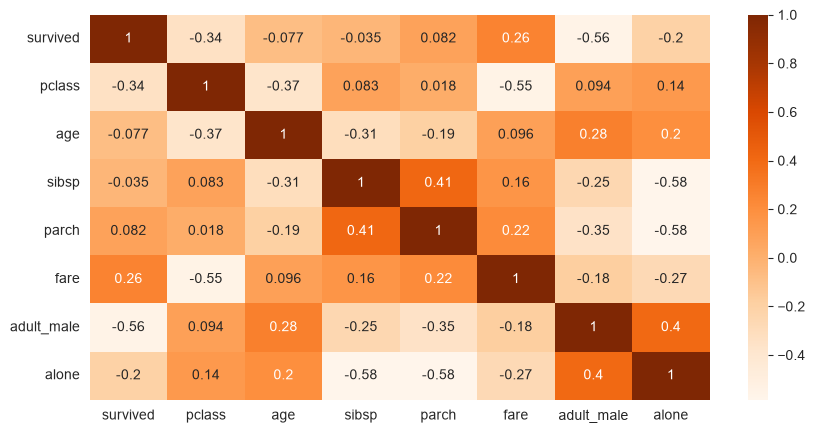

In [345]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_num_col.corr(), annot=True, cmap='Oranges');

Summary:
 The correlation plot shows that survival was most strongly affected by being an adult male (-0.56), passenger class (-0.34), and fare paid (0.26). Adult males were less likely to survive, while passengers in higher classes who paid higher fares were more likely to survive. Most other variables, such as age, had only weak relationships with survival.

In [346]:
df_num_col = df.select_dtypes(include=['number'])
print(df_num_col.columns)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')


In [347]:
corr_matrix = df_num_col.corr()
print(corr_matrix.columns)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')


In [348]:
correlation = abs(df_num_col.corr()['survived'])
correlation

survived    1.000000
pclass      0.338481
age         0.077221
sibsp       0.035322
parch       0.081629
fare        0.257307
Name: survived, dtype: float64

In [349]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [27]:
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [30]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

C:\Users\sabathin\AppData\Local\Temp\ipykernel_25816\3070375709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "survived",data=df, palette="Set3")


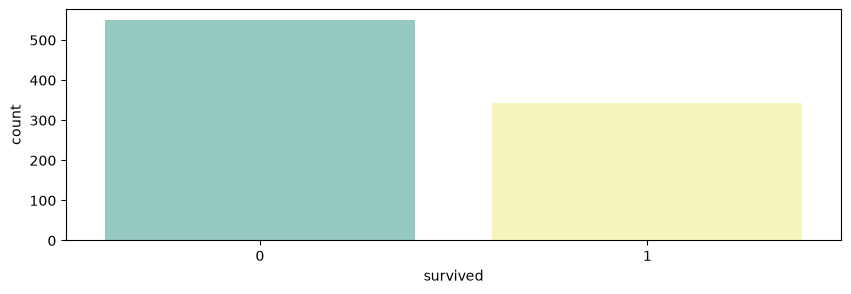

In [31]:
plt.figure(figsize=(10, 3))
sns.countplot(x = "survived",data=df, palette="Set3")
plt.show()

Interpretation:
 The count plot shows that more passengers did not survive (0) than survived (1). Approximately 550 passengers died, while about 340 passengers survived. This indicates that the dataset is somewhat imbalanced, with the majority of passengers not surviving the Titanic disaster.

C:\Users\sabathin\AppData\Local\Temp\ipykernel_25816\2436267233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='survived', col='sex', kind='count', data=df,palette="Set3");


<Figure size 1000x300 with 0 Axes>

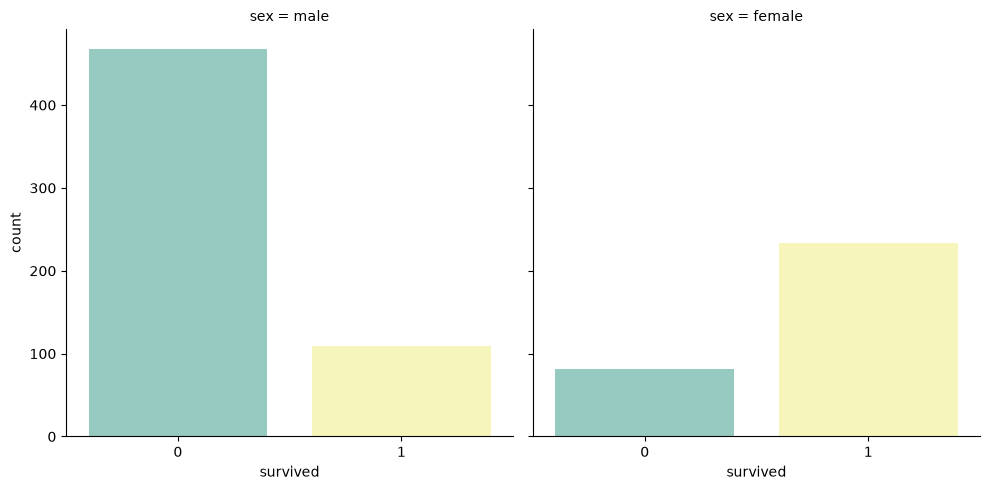

In [32]:
plt.figure(figsize=(10, 3))
sns.catplot(x='survived', col='sex', kind='count', data=df,palette="Set3");
plt.show()

Interpretation:
 The plot shows that most male passengers did not survive, while most female passengers survived. This suggests that gender had a strong impact on survival, with women having a much higher survival rate than men during the Titanic disaster.

C:\Users\sabathin\AppData\Local\Temp\ipykernel_25816\1593408554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='survived', col='pclass', kind='count', data=df,palette="Set3");


<Figure size 1000x300 with 0 Axes>

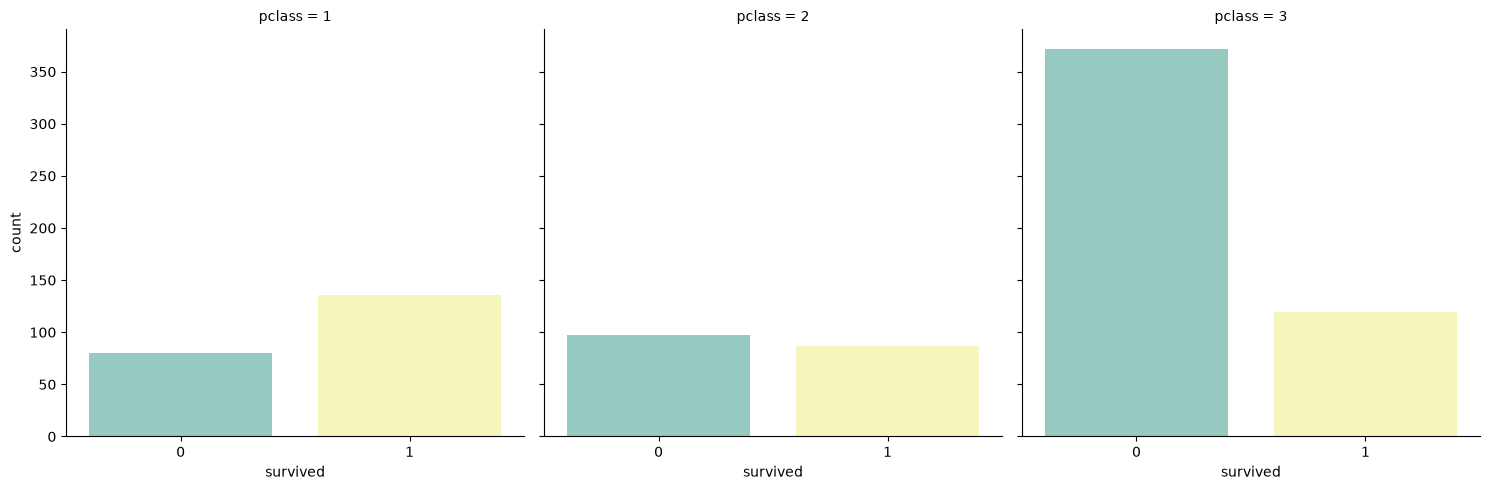

In [33]:
plt.figure(figsize=(10, 3))
sns.catplot(x='survived', col='pclass', kind='count', data=df,palette="Set3");
plt.show()

Interpretation:
 The plot shows that 1st-class passengers had the highest survival rate, as more passengers survived than died. In contrast, 3rd-class passengers had the lowest survival rate, with many more deaths than survivors. 2nd-class passengers had a more balanced outcome, but slightly more passengers did not survive. This suggests that passenger class was an important factor in survival on the Titanic.

<Figure size 1000x300 with 0 Axes>

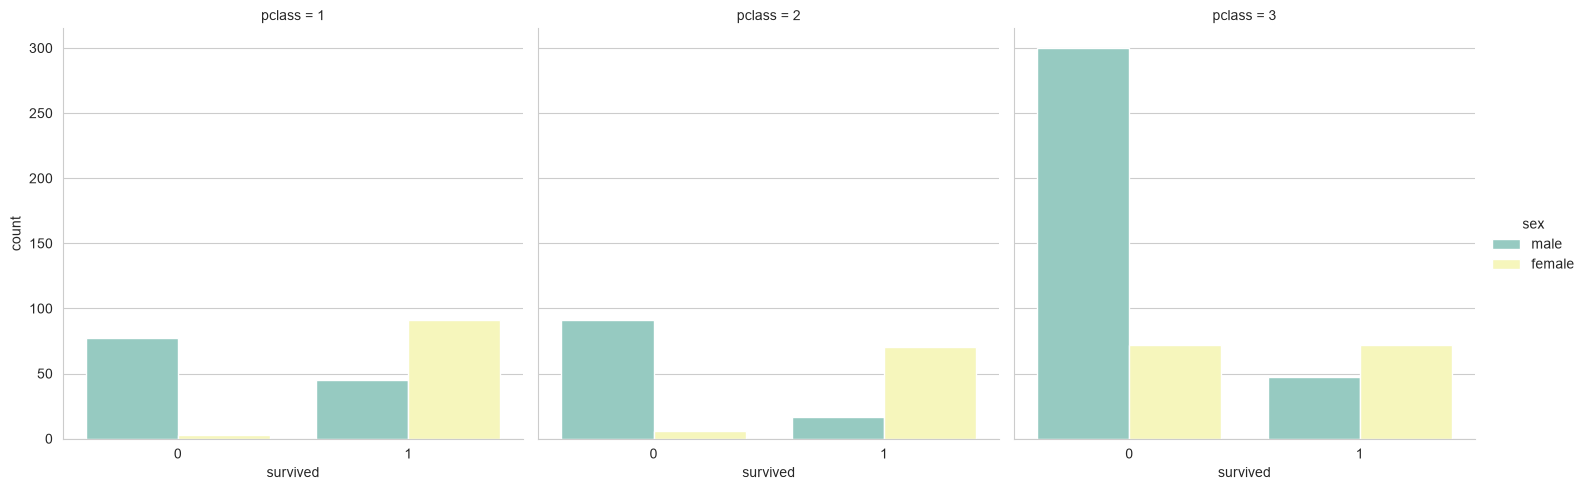

In [34]:
plt.figure(figsize=(10, 3))
sns.set_style('whitegrid')
sns.catplot(x='survived', col='pclass', hue = 'sex', kind='count', data=df,palette="Set3");
plt.show()

C:\Users\sabathin\AppData\Local\Temp\ipykernel_25816\461804785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='survived', col='embarked', kind='count', data=df,palette="Set3");


<Figure size 1000x300 with 0 Axes>

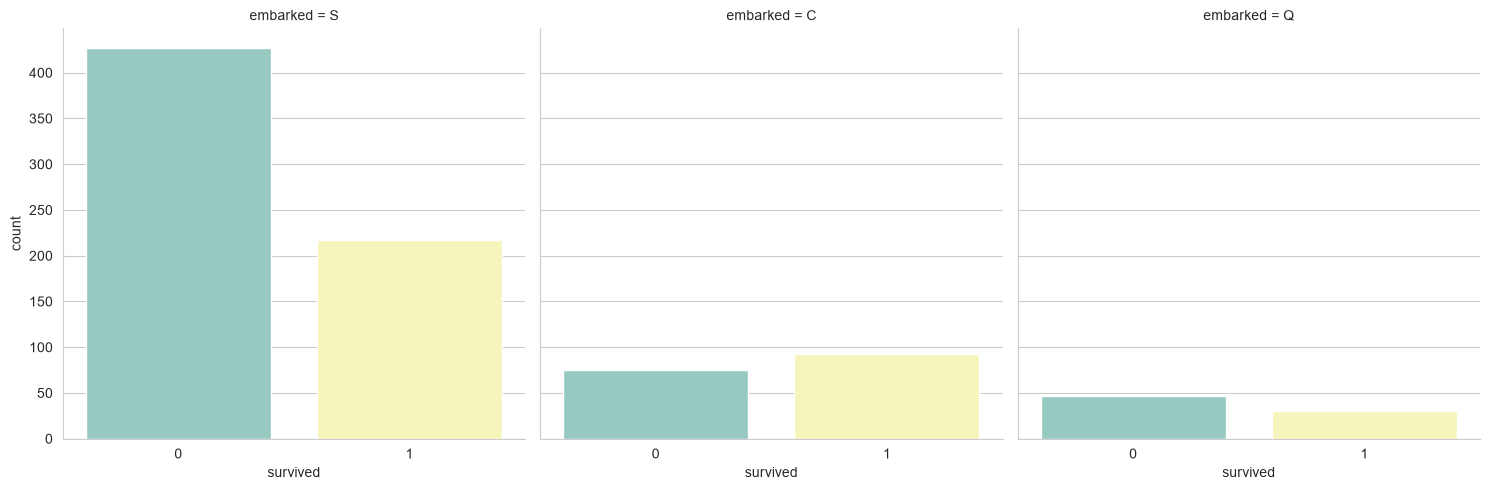

In [35]:
plt.figure(figsize=(10, 3))
sns.set_style('whitegrid')
sns.catplot(x='survived', col='embarked', kind='count', data=df,palette="Set3");
plt.show()

Interpretation:
 The plot shows that passengers who embarked at Cherbourg (C) had a higher survival rate, while those who embarked at Southampton (S) had more deaths than survivors. Passengers who embarked at Queenstown (Q) also had a relatively low survival rate. This suggests that the port of embarkation was associated with survival outcomes, likely due to differences in passenger class distribution.
 

<Figure size 1000x300 with 0 Axes>

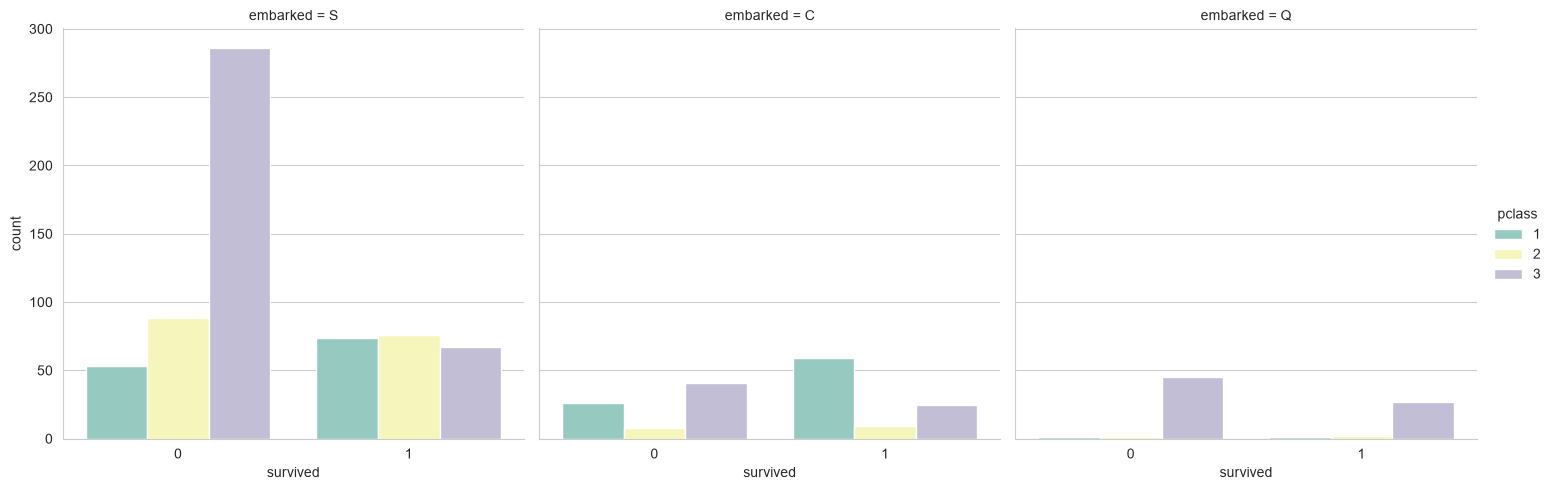

In [36]:
plt.figure(figsize=(10, 3))
sns.set_style('whitegrid')
sns.catplot(x='survived', col='embarked', hue = 'pclass', kind='count', data=df,palette="Set3");
plt.show()

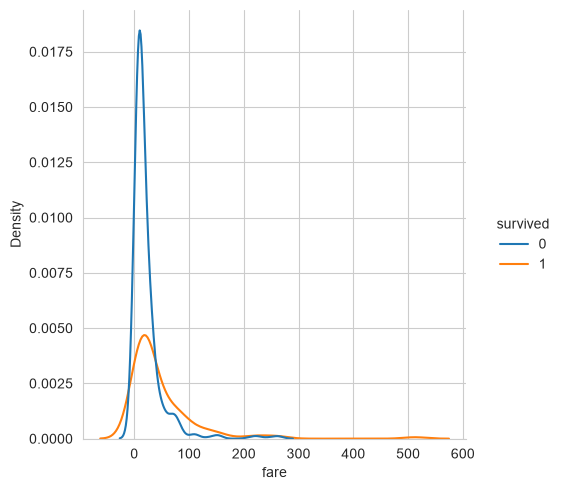

In [ ]:
sns.displot(data=df, x="fare",hue='survived',kind ='kde')

Interpretation:
 The fare distribution shows that passengers who survived generally paid higher fares than those who did not survive. Most passengers paid lower fares, but survival was more common among those with higher ticket prices, suggesting that wealthier passengers (often in higher classes) had better chances of survival.

In [40]:
pip install jinja2

Defaulting to user installation because normal site-packages is not writeable
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
pd.crosstab(df.sex,df.survived,normalize = "index" ).style.background_gradient(cmap='crest')

survived,0,1
sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [42]:
pd.crosstab(df.pclass,df.survived,normalize = "index" ).style.background_gradient(cmap='Spectral_r')

survived,0,1
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In [43]:
pd.crosstab(df.embarked,df.survived,normalize = "index" ).style.background_gradient(cmap='Pastel1')

survived,0,1
embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


Visual Representation of features

<Axes: xlabel='age', ylabel='Count'>

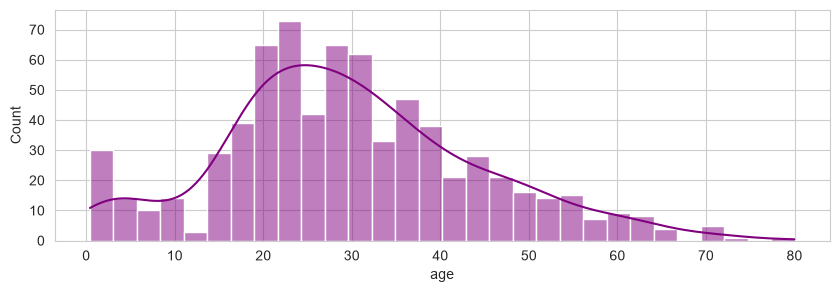

In [45]:
plt.figure(figsize=(10, 3))
sns.histplot(df['age'].dropna(),kde=True,color='purple',bins=30)

Data Preprocessing

Handling missing data of Age

In [49]:
df['age'].isnull().sum()

np.int64(177)

Text(0.5, 1.0, 'Age over Pclass')

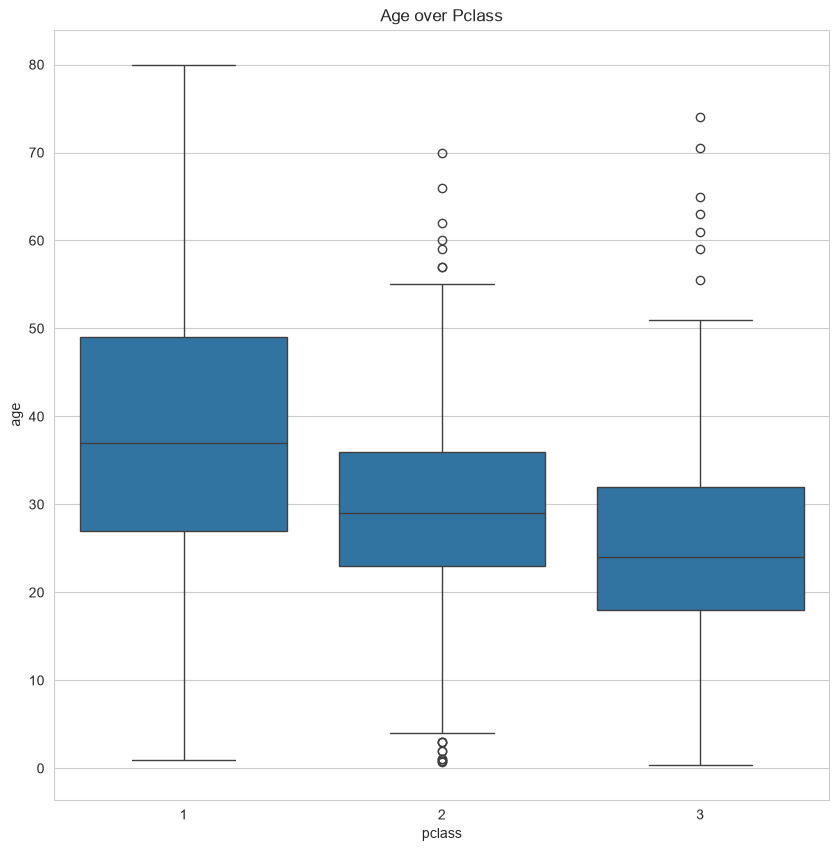

In [51]:
plt.figure(figsize=(10, 10))
sns.boxplot(x='pclass',y='age',data=df)
plt.title('Age over Pclass')

Interpretation:
 The box plot shows that 1st-class passengers were generally older, with a median age around 37 years, while 3rd-class passengers were younger, with a median age around 24 years. There are also several age outliers in all classes, indicating the presence of very young children and elderly passengers.

In [350]:
def impute_df_age(cols):
    age = cols['age']
    pclass = cols['pclass']

    if pd.isnull(age):

        if pclass == 1:
            return 37
        elif pclass == 2:
            return 29
        else:
            return 24
    else:
        return age

In [351]:
df['age'] = df[['age', 'pclass']].apply(impute_df_age, axis=1)

In [78]:
df['age'].isnull().sum()

np.int64(0)

Handling missing data of Cabin

In [79]:
df['deck'].isnull().sum()

np.int64(688)

In [352]:
df.drop('deck',axis=1,inplace=True)

Handling missing data of Embarked

In [63]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [81]:
df.dropna(inplace=True)

In [82]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Encoding Categorical Features

In [353]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  embark_town  889 non-null    str    
 12  alive        891 non-null    str    
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(6)
memory usage: 85.4 KB


In [354]:
import pandas as pd

# Convert boolean columns to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Create dummies for object/string columns
df = pd.get_dummies(
    df,
    columns=df.select_dtypes(include=['object', 'string']).columns,
    drop_first=True  # optional
)

print(df.head())

   survived  pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
0         0       3  22.0      1      0   7.2500           1      0      True   
1         1       1  38.0      1      0  71.2833           0      0     False   
2         1       3  26.0      0      0   7.9250           0      1     False   
3         1       1  35.0      1      0  53.1000           0      0     False   
4         0       3  35.0      0      0   8.0500           1      1      True   

   embarked_Q  embarked_S  class_Second  class_Third  who_man  who_woman  \
0       False        True         False         True     True      False   
1       False       False         False        False    False       True   
2       False        True         False         True    False       True   
3       False        True         False        False    False       True   
4       False        True         False         True     True      False   

   embark_town_Queenstown  embark_town_Southampton  aliv

In [356]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [357]:
df[bool_cols] = df[bool_cols].astype(int)

print(df)

     survived  pclass   age  sibsp  parch     fare  adult_male  alone  \
0           0       3  22.0      1      0   7.2500           1      0   
1           1       1  38.0      1      0  71.2833           0      0   
2           1       3  26.0      0      0   7.9250           0      1   
3           1       1  35.0      1      0  53.1000           0      0   
4           0       3  35.0      0      0   8.0500           1      1   
..        ...     ...   ...    ...    ...      ...         ...    ...   
886         0       2  27.0      0      0  13.0000           1      1   
887         1       1  19.0      0      0  30.0000           0      1   
888         0       3  24.0      1      2  23.4500           0      0   
889         1       1  26.0      0      0  30.0000           1      1   
890         0       3  32.0      0      0   7.7500           1      1   

     sex_male  embarked_Q  embarked_S  class_Second  class_Third  who_man  \
0           1           0           1         

Train and Test Split

In [358]:
X = df.drop(['survived'],axis = 1)
y = df['survived']

In [375]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [376]:
X_train.shape

(623, 17)

In [377]:
X_test.shape

(268, 17)

In [378]:
y_train.shape

(623,)

In [379]:
y_test.shape

(268,)

Feature Scaling

Logistic Regression Model

In [382]:
LogisticRegression_model = LogisticRegression(max_iter=4, random_state=42)
LogisticRegression_model.fit(X_train,y_train)

C:\Users\sabathin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",4
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the

Predicting target

In [383]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_train_pred = LogisticRegression_model.predict(X_train)
y_test_pred = LogisticRegression_model.predict(X_test)

# Probabilities for ROC-AUC
y_train_prob = LogisticRegression_model.predict_proba(X_train)[:,1]
y_test_prob = LogisticRegression_model.predict_proba(X_test)[:,1]

# ==========================
# TRAIN METRICS
# ==========================
print("TRAIN SET METRICS")
print("-"*50)

print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))
print("ROC AUC  :", roc_auc_score(y_train, y_train_prob))

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

# ==========================
# TEST METRICS
# ==========================
print("\nTEST SET METRICS")
print("-"*50)

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

TRAIN SET METRICS
--------------------------------------------------
Accuracy : 0.6934189406099518
Precision: 0.6935483870967742
Recall   : 0.3598326359832636
F1 Score : 0.4738292011019284
ROC AUC  : 0.7043889470013946

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.90      0.78       384
           1       0.69      0.36      0.47       239

    accuracy                           0.69       623
   macro avg       0.69      0.63      0.63       623
weighted avg       0.69      0.69      0.66       623


TEST SET METRICS
--------------------------------------------------
Accuracy : 0.6343283582089553
Precision: 0.5384615384615384
Recall   : 0.33980582524271846
F1 Score : 0.4166666666666667
ROC AUC  : 0.6478964401294499

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.82      0.73       165
           1       0.54      0.34      0.42       103

    accuracy          

In [386]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=4, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())


CV Scores: [0.59776536 0.7247191  0.66853933 0.68539326 0.67977528]
Mean CV Accuracy: 0.6712384658841253


C:\Users\sabathin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sabathin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 4 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

Confusion Matrix (Train & Test)

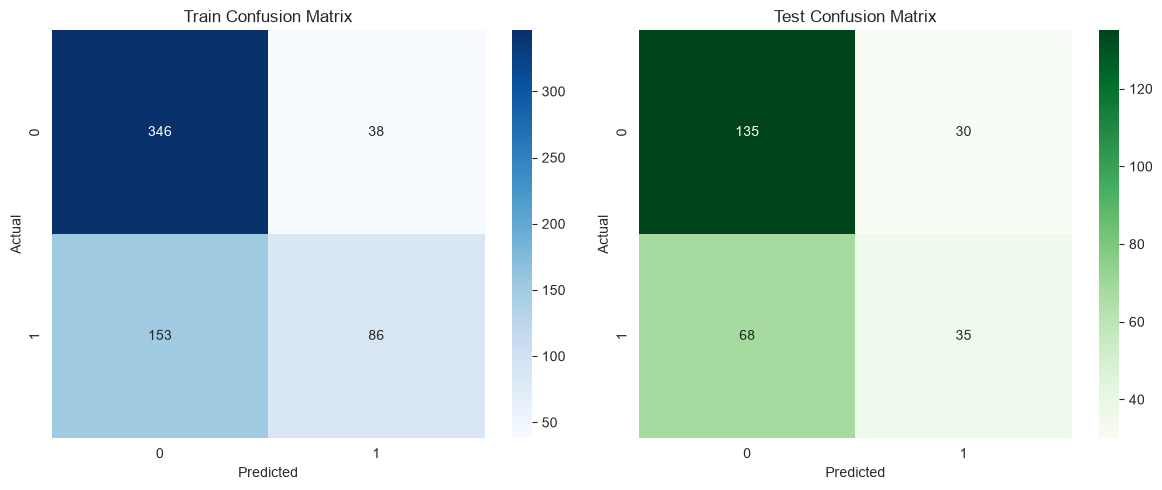

In [387]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Train
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax[0])
ax[0].set_title('Train Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Test
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test,
            annot=True,
            fmt='d',
            cmap='Greens',
            ax=ax[1])
ax[1].set_title('Test Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Interpretation:
 The logistic regression model performs better at predicting non-survivors (0) than survivors (1). On the test set, it correctly identified 135 non-survivors and 35 survivors, but misclassified 68 survivors as non-survivors. This suggests the model is biased toward predicting the majority class (non-survival) and may need further tuning or feature engineering to improve survivor prediction.

ROC Curve (Train & Test)

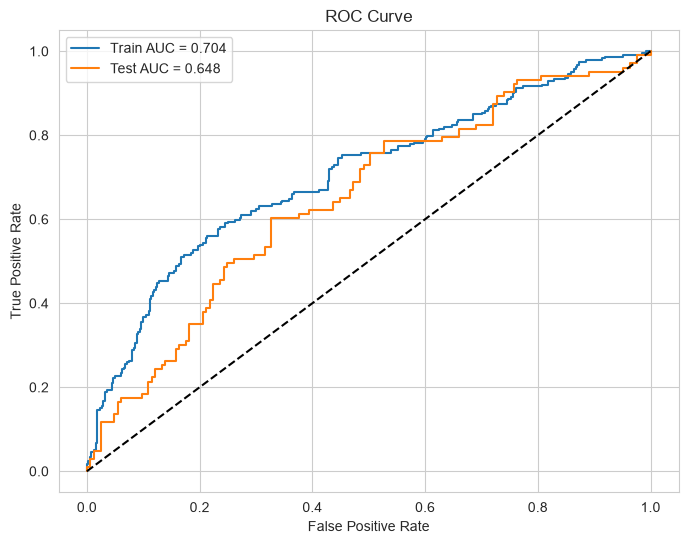

In [388]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_train,
    tpr_train,
    label=f'Train AUC = {roc_auc_score(y_train, y_train_prob):.3f}'
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f'Test AUC = {roc_auc_score(y_test, y_test_prob):.3f}'
)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Interpretation:
 The ROC curve shows that the logistic regression model performs better than random guessing. The Train AUC is 0.704 and the Test AUC is 0.648, indicating moderate predictive ability. The lower Test AUC suggests the model's performance decreases on unseen data, but it still has some ability to distinguish between survivors and non-survivors.

Metrics Comparison Plot

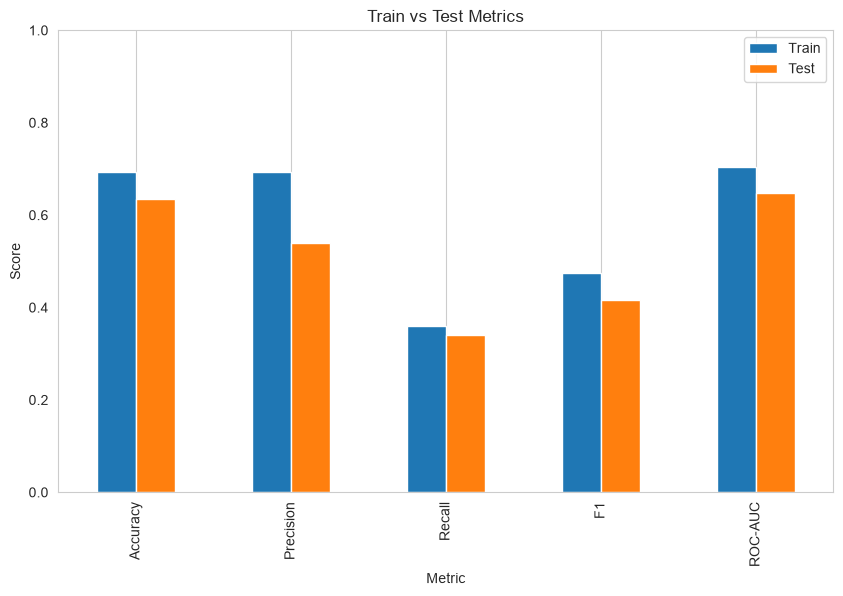

      Metric     Train      Test
0   Accuracy  0.693419  0.634328
1  Precision  0.693548  0.538462
2     Recall  0.359833  0.339806
3         F1  0.473829  0.416667
4    ROC-AUC  0.704389  0.647896


In [389]:
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1','ROC-AUC'],
    'Train':[
        accuracy_score(y_train,y_train_pred),
        precision_score(y_train,y_train_pred),
        recall_score(y_train,y_train_pred),
        f1_score(y_train,y_train_pred),
        roc_auc_score(y_train,y_train_prob)
    ],
    'Test':[
        accuracy_score(y_test,y_test_pred),
        precision_score(y_test,y_test_pred),
        recall_score(y_test,y_test_pred),
        f1_score(y_test,y_test_pred),
        roc_auc_score(y_test,y_test_prob)
    ]
})

metrics_df.set_index('Metric').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Train vs Test Metrics')
plt.ylabel('Score')
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

print(metrics_df)

Interpretation:
 The model achieves moderate performance, with a test accuracy of about 63% and a ROC-AUC of 0.65. The gap between train and test metrics is small, indicating limited overfitting and reasonable generalization. However, the relatively low recall suggests the model misses many actual survivors, leaving room for improvement.

Overfitting Check

In [390]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Gap            : {abs(train_acc-test_acc):.4f}")

Train Accuracy : 0.6934
Test Accuracy  : 0.6343
Gap            : 0.0591


Interpretation:
 The model shows minimal overfitting, as the training accuracy (69.34%) and test accuracy (63.43%) are relatively close. The accuracy gap of 5.91% suggests that the model generalizes reasonably well to unseen data, although there is still some room for improvement in predictive performance.

In [109]:
y_pred = LogisticRegression_model.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1])

Evaluation

Confusion Matrix

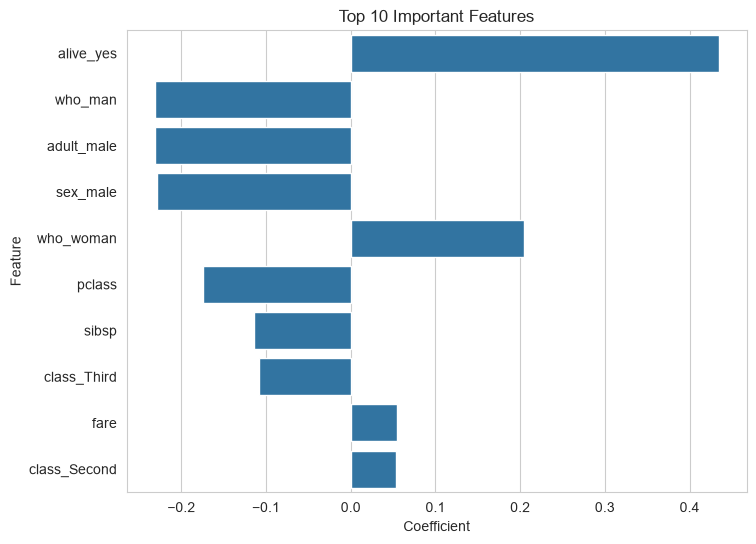

In [123]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

plt.figure(figsize=(8,6))
sns.barplot(
    data=coef_df.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()

In [364]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_train_pred = LogisticRegression_model.predict(X_train)
y_test_pred = LogisticRegression_model.predict(X_test)

# Probabilities for ROC-AUC
y_train_prob = LogisticRegression_model.predict_proba(X_train)[:,1]
y_test_prob = LogisticRegression_model.predict_proba(X_test)[:,1]

# ==========================
# TRAIN METRICS
# ==========================
print("TRAIN SET METRICS")
print("-"*50)

print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))
print("ROC AUC  :", roc_auc_score(y_train, y_train_prob))

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

# ==========================
# TEST METRICS
# ==========================
print("\nTEST SET METRICS")
print("-"*50)

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

TRAIN SET METRICS
--------------------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 0.9999999999999999

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       384
           1       1.00      1.00      1.00       239

    accuracy                           1.00       623
   macro avg       1.00      1.00      1.00       623
weighted avg       1.00      1.00      1.00       623


TEST SET METRICS
--------------------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 0.9999999999999999

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       165
           1       1.00      1.00      1.00       103

    accuracy                           1.00       268
   macro avg       1.00      1.00      1.00       268
weighted avg       1.00      1.00  

Decision tree

Imported required Libraries

In [124]:
pip install pandas numpy matplotlib seaborn scikit-learn graphviz CHAID

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 2.9/2.9 MB 25.0 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [graphviz]
   ---------- ----------------------------- 1/4 [graphviz]
   ---------- ----------------------------- 1/4 [graphviz]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- ------------------- 2/4 [cython]
   -------------------- -------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import Libraries

In [128]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

from CHAID import Tree

Load Dataset

In [207]:
df = pd.read_csv("titanic.csv")

print(df.head())
print(df.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  

Select Features

In [208]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Data Preparation

In [209]:
import pandas as pd
import numpy as np

# Copy data
df_chaid = df.copy()

# Remove leakage column
df_chaid = df_chaid.drop(columns=['alive'])

# Fill missing values
df_chaid['age'] = df_chaid['age'].fillna(df_chaid['age'].median())
df_chaid['fare'] = df_chaid['fare'].fillna(df_chaid['fare'].median())

df_chaid['deck'] = df_chaid['deck'].fillna('Unknown')
df_chaid['embarked'] = df_chaid['embarked'].fillna('Unknown')
df_chaid['embark_town'] = df_chaid['embark_town'].fillna('Unknown')

Convert Continuous Variables into Categories

In [210]:
df_chaid['age_bin'] = pd.cut(
    df_chaid['age'],
    bins=[0,18,35,50,80],
    labels=['Child','Young','Adult','Senior']
)

df_chaid['fare_bin'] = pd.qcut(
    df_chaid['fare'],
    q=4,
    labels=['Low','Medium','High','Very_High']
)

df_chaid = df_chaid.drop(columns=['age','fare'])

Train-Test Split

In [153]:
from sklearn.model_selection import train_test_split

X = df_chaid.drop('survived', axis=1)
y = df_chaid['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Build CHAID Tree

In [154]:
from CHAID import Tree

train_data = X_train.copy()
train_data['survived'] = y_train

variable_types = {
    col: 'nominal'
    for col in X_train.columns
}

tree = Tree.from_pandas_df(
    train_data,
    variable_types,
    'survived'
)

tree.print_tree()

([], {0: 384.0, 1: 239.0}, (who, p=2.1037884633376778e-46, score=204.56820491508557, groups=[['child', 'woman'], ['man']]), dof=1))
|-- (['child', 'woman'], {0: 64.0, 1: 177.0}, (pclass, p=1.1006122782483927e-14, score=59.70741248225933, groups=[[1, 2], [3]]), dof=1))
|   |-- ([1, 2], {0: 7.0, 1: 119.0}, <Invalid Chaid Split> - the max depth has been reached)
|   +-- ([3], {0: 57.0, 1: 58.0}, <Invalid Chaid Split> - the max depth has been reached)
+-- (['man'], {0: 320.0, 1: 62.0}, (deck, p=2.8569192939941604e-10, score=39.770054839725304, groups=[['A', 'C', 'B', 'D', 'E'], ['F', 'Unknown']]), dof=1))
    |-- (['A', 'C', 'B', 'D', 'E'], {0: 33.0, 1: 26.0}, <Invalid Chaid Split> - the max depth has been reached)
    +-- (['F', 'Unknown'], {0: 287.0, 1: 36.0}, <Invalid Chaid Split> - the max depth has been reached)



Visualize Tree

In [156]:
tree.to_tree()

In [159]:
import plotly
import CHAID

print(plotly.__version__)

7.1.0


In [160]:
tree.print_tree()

([], {0: 384.0, 1: 239.0}, (who, p=2.1037884633376778e-46, score=204.56820491508557, groups=[['child', 'woman'], ['man']]), dof=1))
|-- (['child', 'woman'], {0: 64.0, 1: 177.0}, (pclass, p=1.1006122782483927e-14, score=59.70741248225933, groups=[[1, 2], [3]]), dof=1))
|   |-- ([1, 2], {0: 7.0, 1: 119.0}, <Invalid Chaid Split> - the max depth has been reached)
|   +-- ([3], {0: 57.0, 1: 58.0}, <Invalid Chaid Split> - the max depth has been reached)
+-- (['man'], {0: 320.0, 1: 62.0}, (deck, p=2.8569192939941604e-10, score=39.770054839725304, groups=[['A', 'C', 'B', 'D', 'E'], ['F', 'Unknown']]), dof=1))
    |-- (['A', 'C', 'B', 'D', 'E'], {0: 33.0, 1: 26.0}, <Invalid Chaid Split> - the max depth has been reached)
    +-- (['F', 'Unknown'], {0: 287.0, 1: 36.0}, <Invalid Chaid Split> - the max depth has been reached)



In [161]:
print(tree.to_tree())

([], {0: 384.0, 1: 239.0}, (who, p=2.1037884633376778e-46, score=204.56820491508557, groups=[['child', 'woman'], ['man']]), dof=1))
├── (['child', 'woman'], {0: 64.0, 1: 177.0}, (pclass, p=1.1006122782483927e-14, score=59.70741248225933, groups=[[1, 2], [3]]), dof=1))
│   ├── ([1, 2], {0: 7.0, 1: 119.0}, <Invalid Chaid Split> - the max depth has been reached)
│   └── ([3], {0: 57.0, 1: 58.0}, <Invalid Chaid Split> - the max depth has been reached)
└── (['man'], {0: 320.0, 1: 62.0}, (deck, p=2.8569192939941604e-10, score=39.770054839725304, groups=[['A', 'C', 'B', 'D', 'E'], ['F', 'Unknown']]), dof=1))
    ├── (['A', 'C', 'B', 'D', 'E'], {0: 33.0, 1: 26.0}, <Invalid Chaid Split> - the max depth has been reached)
    └── (['F', 'Unknown'], {0: 287.0, 1: 36.0}, <Invalid Chaid Split> - the max depth has been reached)



In [169]:
import plotly
print(plotly.__version__)

7.1.0


In [171]:
pip install -U kaleido

Defaulting to user installation because normal site-packages is not writeable
  Using cached orjson-3.12.0-cp314-cp314-win_amd64.whl.metadata (43 kB)
Using cached orjson-3.12.0-cp314-cp314-win_amd64.whl (121 kB)

   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------- ----------------------- 2/5 [logistro]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [ka


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [173]:
from IPython.display import display

print(tree.to_tree())

([], {0: 384.0, 1: 239.0}, (who, p=2.1037884633376778e-46, score=204.56820491508557, groups=[['child', 'woman'], ['man']]), dof=1))
├── (['child', 'woman'], {0: 64.0, 1: 177.0}, (pclass, p=1.1006122782483927e-14, score=59.70741248225933, groups=[[1, 2], [3]]), dof=1))
│   ├── ([1, 2], {0: 7.0, 1: 119.0}, <Invalid Chaid Split> - the max depth has been reached)
│   └── ([3], {0: 57.0, 1: 58.0}, <Invalid Chaid Split> - the max depth has been reached)
└── (['man'], {0: 320.0, 1: 62.0}, (deck, p=2.8569192939941604e-10, score=39.770054839725304, groups=[['A', 'C', 'B', 'D', 'E'], ['F', 'Unknown']]), dof=1))
    ├── (['A', 'C', 'B', 'D', 'E'], {0: 33.0, 1: 26.0}, <Invalid Chaid Split> - the max depth has been reached)
    └── (['F', 'Unknown'], {0: 287.0, 1: 36.0}, <Invalid Chaid Split> - the max depth has been reached)



In [175]:
import kaleido
print("Kaleido installed successfully")

Kaleido installed successfully


In [176]:
import plotly.io as pio
print(pio.renderers)

Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype+notebook_connected'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [179]:
def bar_chart(self, node):
    fig["data"].append(self._table(node))
    filename = os.path.join(
        self.tempdir,
        "node-{}.png".format(node.node_id)
    )
    pio.write_image(fig, file=filename, format="png", engine="orca")
    return filename

In [182]:
import CHAID.graph as graph

print(graph.__file__)

C:\Users\sabathin\AppData\Roaming\Python\Python314\site-packages\CHAID\graph.py


Step 1: Prepare Features and Target

In [211]:
from sklearn.model_selection import train_test_split
from sklearn import tree

# Features (X) and target (y)
X = df_chaid.drop('survived', axis=1)
y = df_chaid['survived']

Step 2: Split Data into Training and Testing Sets

In [212]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 20% test data
    random_state=42,
    stratify=y          # optional for classification
)

Step 3: Build the Decision Tree Model

In [194]:
X_train.head()

,pclass,sex,sibsp,parch,embarked,class,who,adult_male,deck,embark_town,alone,age_bin,fare_bin
748,1,male,1,0,S,First,man,True,D,Southampton,False,Young,Very_High
45,3,male,0,0,S,Third,man,True,Unknown,Southampton,True,Young,Medium
28,3,female,0,0,Q,Third,woman,False,Unknown,Queenstown,True,Young,Low
633,1,male,0,0,S,First,man,True,Unknown,Southampton,True,Young,Low
403,3,male,1,0,S,Third,man,True,Unknown,Southampton,False,Young,High


In [196]:
X_train.dtypes

pclass            int64
sex                 str
sibsp             int64
parch             int64
embarked            str
class               str
who                 str
adult_male         bool
deck                str
embark_town         str
alone              bool
age_bin        category
fare_bin       category
dtype: object

##Craete Dummy Variable

In [217]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_train['sex'] = le.fit_transform(X_train['sex'])
X_test['sex'] = le.transform(X_test['sex'])
X_train['class'] = le.fit_transform(X_train['class'])
X_test['class'] = le.transform(X_test['class'])
X_train['who'] = le.fit_transform(X_train['who'])
X_test['who'] = le.transform(X_test['who'])
X_train['adult_male'] = le.fit_transform(X_train['adult_male'])
X_test['adult_male'] = le.transform(X_test['adult_male'])
X_train['deck'] = le.fit_transform(X_train['deck'])
X_test['deck'] = le.transform(X_test['deck'])
X_train['embark_town'] = le.fit_transform(X_train['embark_town'])
X_test['embark_town'] = le.transform(X_test['embark_town'])
X_train['alone'] = le.fit_transform(X_train['alone'])
X_test['alone'] = le.transform(X_test['alone'])
X_train['age_bin'] = le.fit_transform(X_train['age_bin'])
X_test['age_bin'] = le.transform(X_test['age_bin'])
X_train['fare_bin'] = le.fit_transform(X_train['fare_bin'])
X_test['fare_bin'] = le.transform(X_test['fare_bin'])
X_train['embarked'] = le.fit_transform(X_train['embarked'])
X_test['embarked'] = le.transform(X_test['embarked'])

In [218]:
X_train.head()

,pclass,sex,sibsp,parch,embarked,class,who,adult_male,deck,embark_town,alone,age_bin,fare_bin
748,1,1,1,0,2,0,1,1,3,2,0,3,3
45,3,1,0,0,2,2,1,1,7,2,1,3,2
28,3,0,0,0,1,2,2,0,7,1,1,3,1
633,1,1,0,0,2,0,1,1,7,2,1,3,1
403,3,1,1,0,2,2,1,1,7,2,0,3,0


In [219]:
X_train.dtypes

pclass         int64
sex            int64
sibsp          int64
parch          int64
embarked       int64
class          int64
who            int64
adult_male     int64
deck           int64
embark_town    int64
alone          int64
age_bin        int64
fare_bin       int64
dtype: object

## Bulid Decision tree (CHAID) model

In [220]:
decision_tree = tree.DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

decision_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

Step 4: Make Predictions

In [221]:
y_pred = decision_tree.predict(X_test)

Step 5: Evaluate the Model

In [222]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7873134328358209

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       165
           1       0.78      0.62      0.69       103

    accuracy                           0.79       268
   macro avg       0.79      0.76      0.76       268
weighted avg       0.79      0.79      0.78       268



Step 6: Export the Tree

In [223]:
from sklearn.tree import export_graphviz

with open("tree1.dot", "w") as f:
    export_graphviz(
        decision_tree,
        out_file=f,
        max_depth=3,
        impurity=True,
        feature_names=list(X.columns),
        class_names=['Died', 'Survived'],
        rounded=True,
        filled=True
    )

Step 7: Convert DOT to PNG

In [230]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

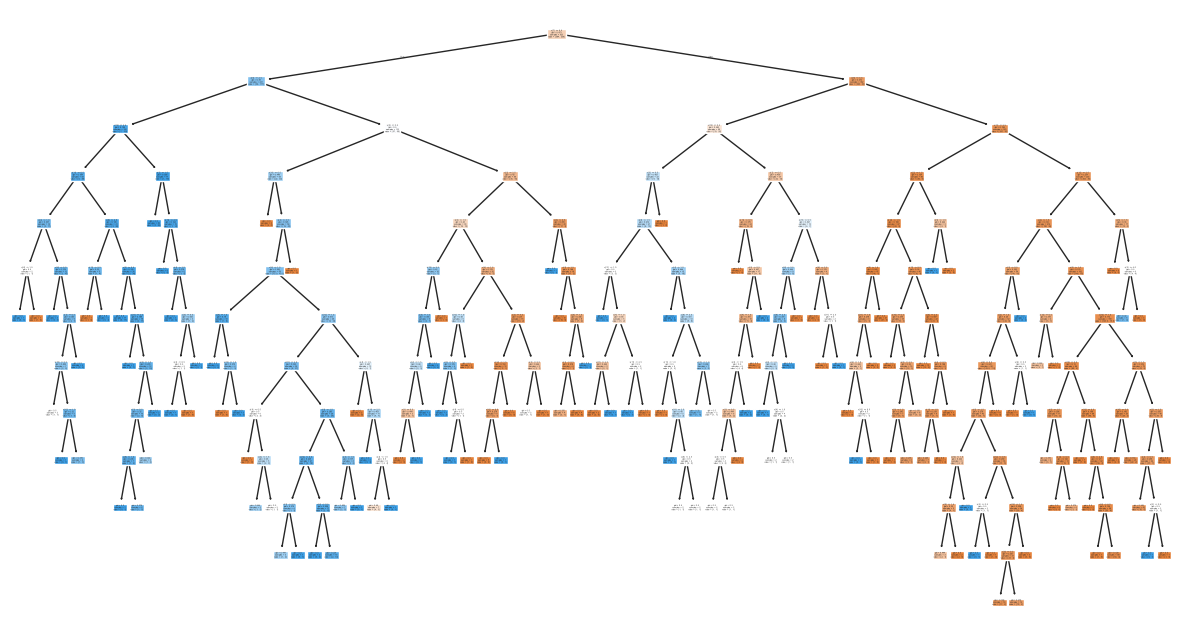

In [231]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
tree.plot_tree(model, filled=True)
plt.show()

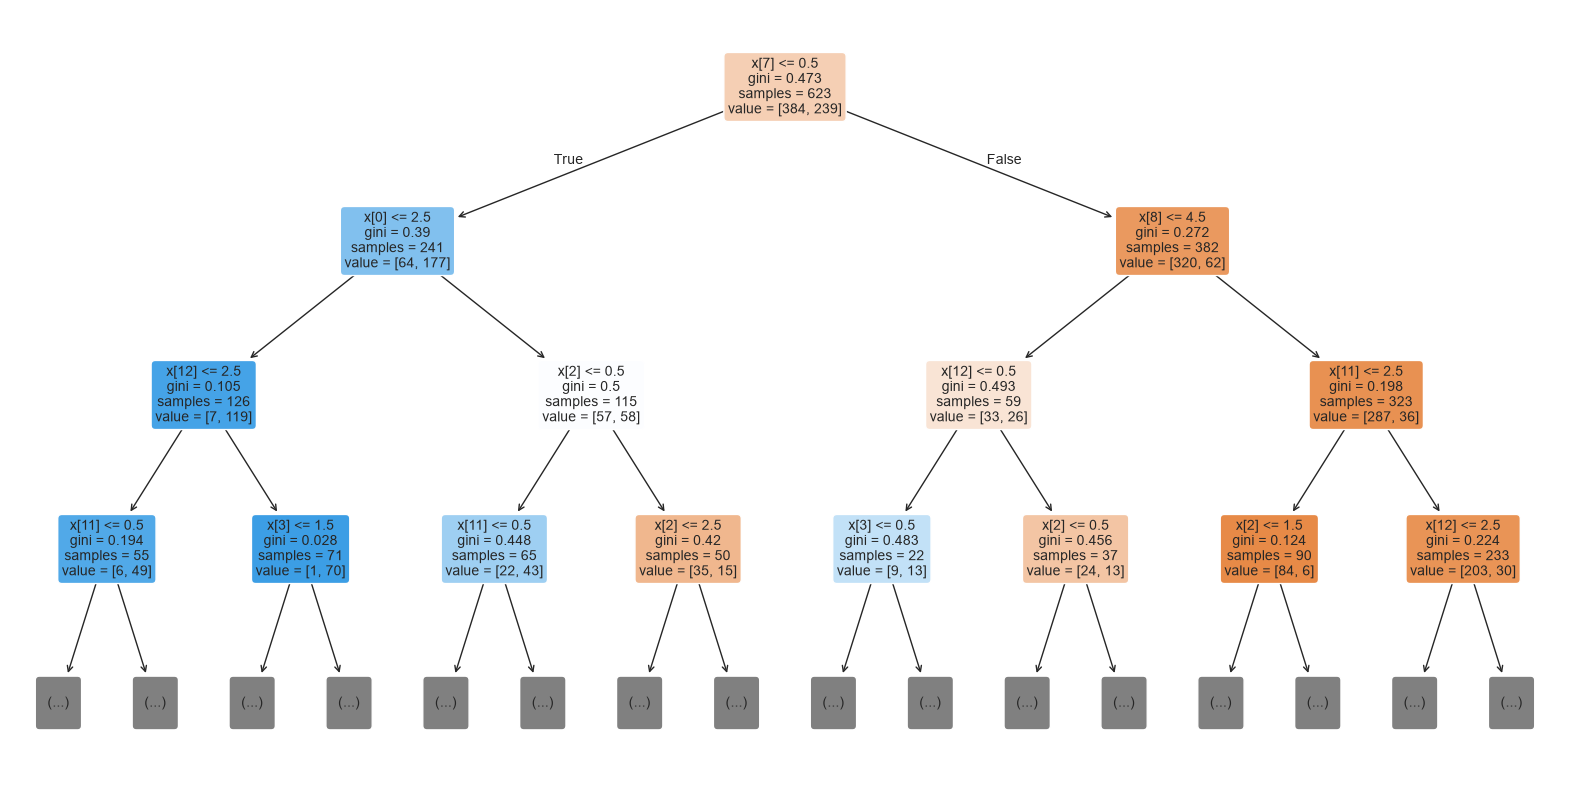

In [236]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
tree.plot_tree(
    model,
    max_depth=3,      # show only first 3 levels
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [266]:
from sklearn.tree import DecisionTreeClassifier

simple_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

simple_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples 

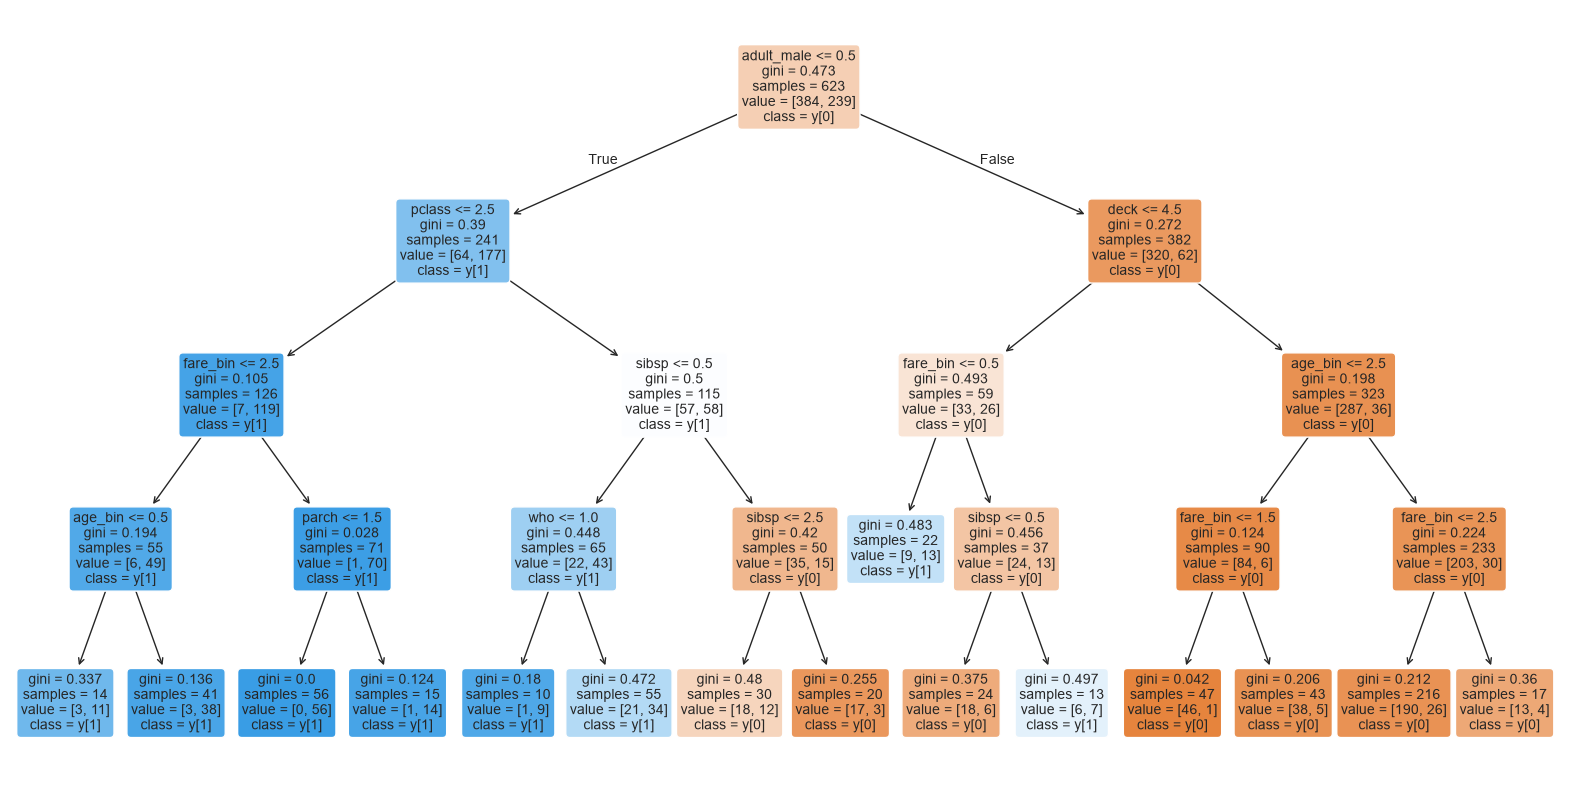

In [238]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    simple_model,
    filled=True,
    rounded=True,
    fontsize=10,
    feature_names=X.columns,
    class_names=True
)
plt.show()

The Decision Tree model revealed that adult male status was the most important factor influencing survival on the Titanic. The tree showed that women and children had significantly higher survival rates, especially those traveling in 1st and 2nd class, where survival was often above 90%. In contrast, adult males had the lowest chances of survival, with most being classified as non-survivors. Among adult males, factors such as deck location, fare, age, and family size further influenced survival outcomes, but none were as impactful as gender and age status. Overall, the model indicates that gender, passenger class, and fare were the strongest predictors of survival, closely reflecting the historical "women and children first" evacuation policy followed during the Titanic disaster.

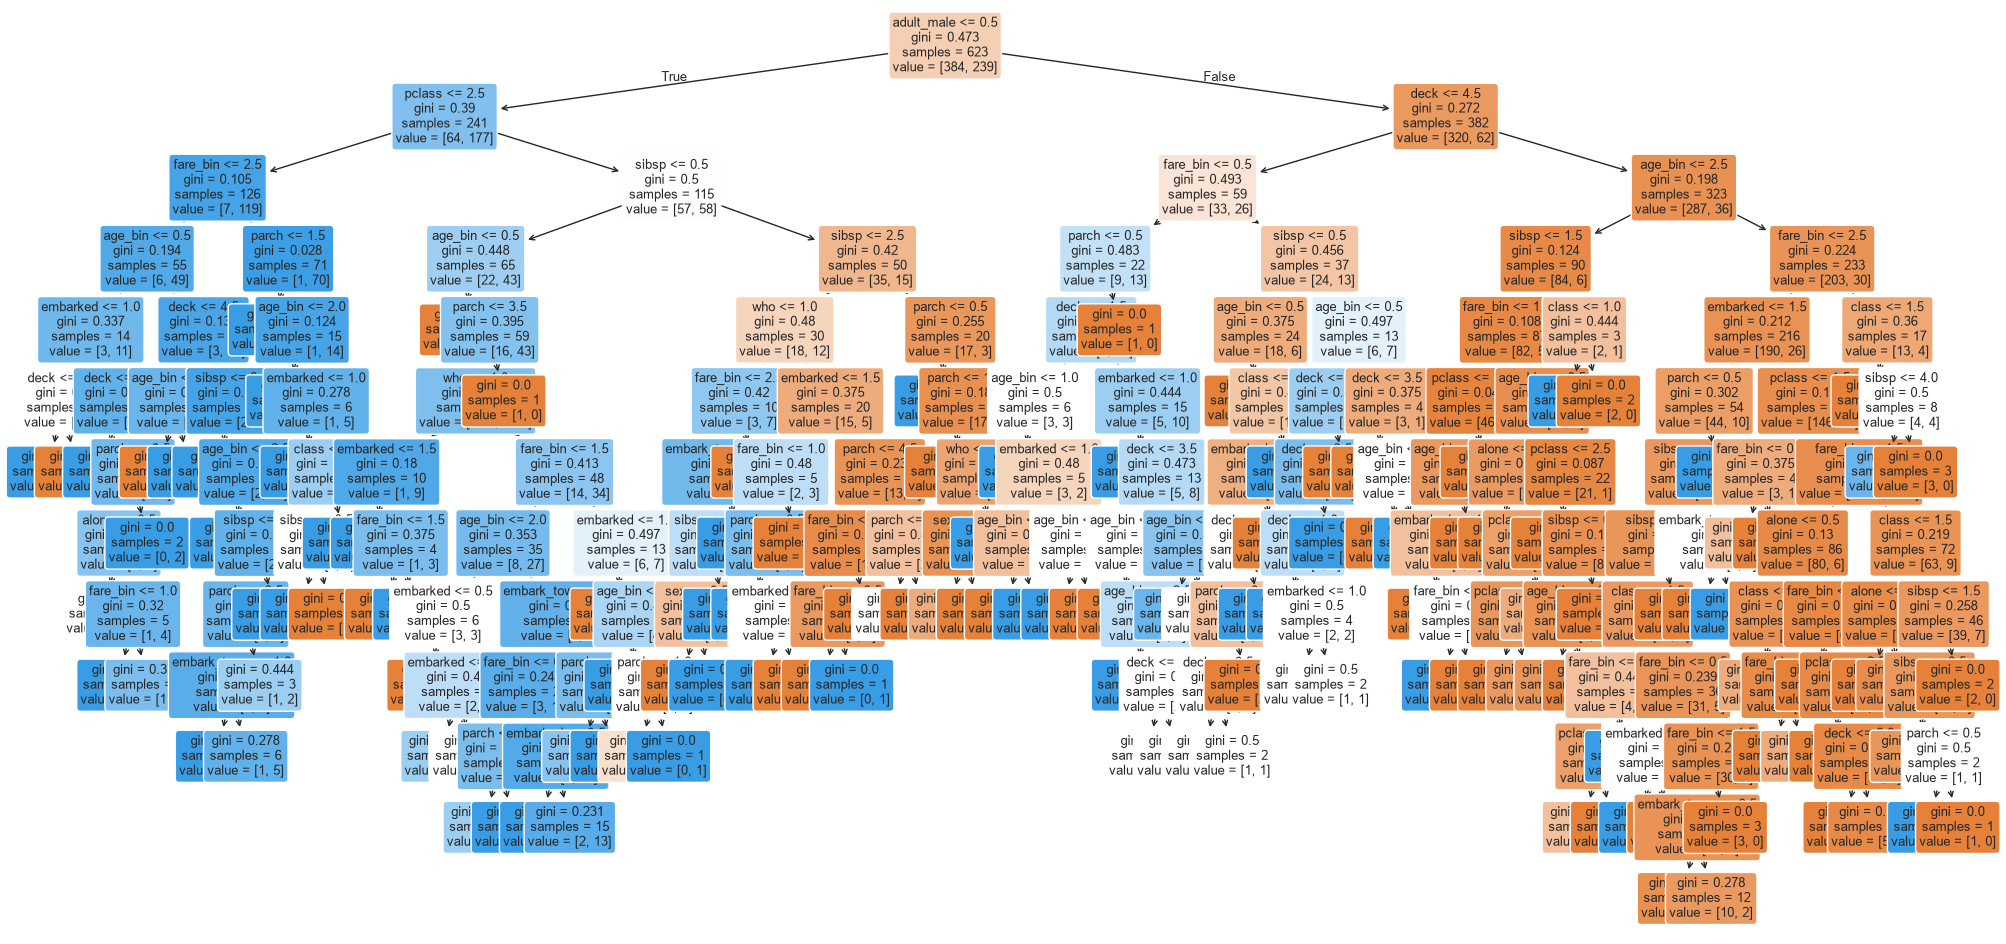

In [239]:
plt.figure(figsize=(25,12))

tree.plot_tree(
    model,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    fontsize=9
)

plt.show()

In [273]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [274]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy :", accuracy_score(y_test, y_test_pred))

# Precision
print("Training Precision:", precision_score(y_train, y_train_pred))
print("Testing Precision :", precision_score(y_test, y_test_pred))

# Recall
print("Training Recall:", recall_score(y_train, y_train_pred))
print("Testing Recall :", recall_score(y_test, y_test_pred))

# F1 Score
print("Training F1:", f1_score(y_train, y_train_pred))
print("Testing F1 :", f1_score(y_test, y_test_pred))

# Confusion Matrix
print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, y_train_pred))

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred))

# Detailed Classification Report
print("\nTraining Classification Report")
print(classification_report(y_train, y_train_pred))

print("\nTesting Classification Report")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 0.9213483146067416
Testing Accuracy : 0.7723880597014925
Training Precision: 0.9481132075471698
Testing Precision : 0.7386363636363636
Training Recall: 0.8410041841004184
Testing Recall : 0.6310679611650486
Training F1: 0.8913525498891353
Testing F1 : 0.680628272251309

Training Confusion Matrix
[[373  11]
 [ 38 201]]

Testing Confusion Matrix
[[142  23]
 [ 38  65]]

Training Classification Report
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       384
           1       0.95      0.84      0.89       239

    accuracy                           0.92       623
   macro avg       0.93      0.91      0.91       623
weighted avg       0.92      0.92      0.92       623


Testing Classification Report
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       165
           1       0.74      0.63      0.68       103

    accuracy                           0.77       268
   m

ROC-AUC (for binary classification)

In [275]:
# Probability predictions
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

print("Training ROC-AUC:", roc_auc_score(y_train, y_train_prob))
print("Testing ROC-AUC :", roc_auc_score(y_test, y_test_prob))

Training ROC-AUC: 0.9728578277545328
Testing ROC-AUC : 0.7445130920859075


Evaluate all metrics together

In [276]:
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)

    print(f"\n{dataset_name}")
    print("-" * 30)
    print("Accuracy :", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred, average='weighted'))
    print("Recall   :", recall_score(y, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y, y_pred, average='weighted'))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y, y_pred))

    print("\nClassification Report:")
    print(classification_report(y, y_pred))

evaluate_model(model, X_train, y_train, "Training Set")
evaluate_model(model, X_test, y_test, "Testing Set")


Training Set
------------------------------
Accuracy : 0.9213483146067416
Precision: 0.9231065922451638
Recall   : 0.9213483146067416
F1 Score : 0.9203295905219926

Confusion Matrix:
[[373  11]
 [ 38 201]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       384
           1       0.95      0.84      0.89       239

    accuracy                           0.92       623
   macro avg       0.93      0.91      0.91       623
weighted avg       0.92      0.92      0.92       623


Testing Set
------------------------------
Accuracy : 0.7723880597014925
Precision: 0.7695754183627318
Recall   : 0.7723880597014925
F1 Score : 0.7683985037253975

Confusion Matrix:
[[142  23]
 [ 38  65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       165
           1       0.74      0.63      0.68       103

    accuracy                           0.77     

Confusion Matrix (Train & Test)

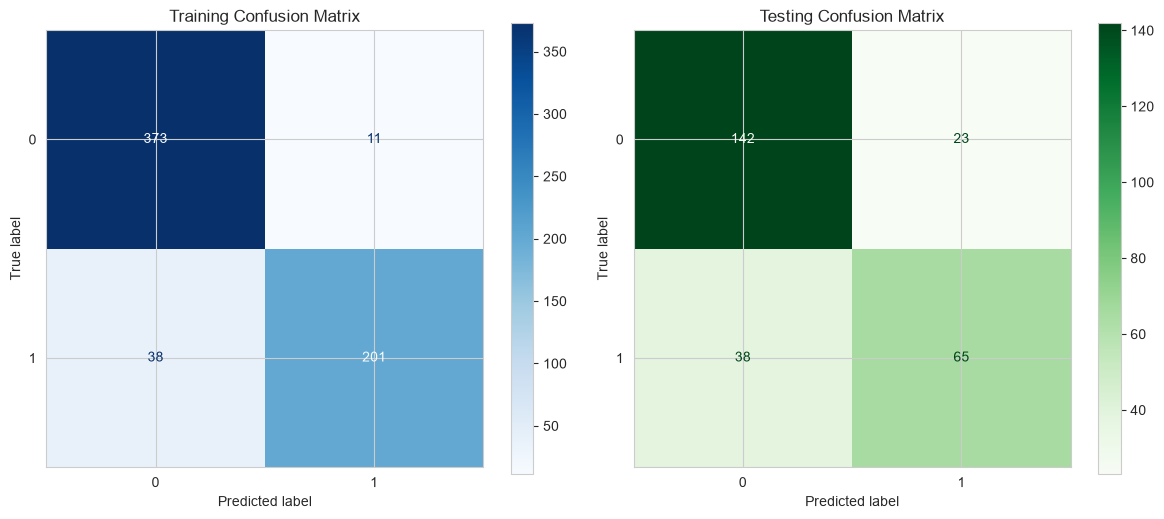

In [278]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    model, X_train, y_train, ax=ax[0], cmap="Blues"
)
ax[0].set_title("Training Confusion Matrix")

ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, ax=ax[1], cmap="Greens"
)
ax[1].set_title("Testing Confusion Matrix")

plt.tight_layout()
plt.show()

Interpretation:
 The confusion matrices show that the Decision Tree model performs well in identifying both survivors and non-survivors. On the test set, it correctly classified 142 non-survivors and 65 survivors, while making relatively few errors (23 false positives and 38 false negatives). The model demonstrates strong predictive performance and appears to generalize well, as the testing results are similar to the training results with no major signs of overfitting.


ROC Curve (Binary Classification)

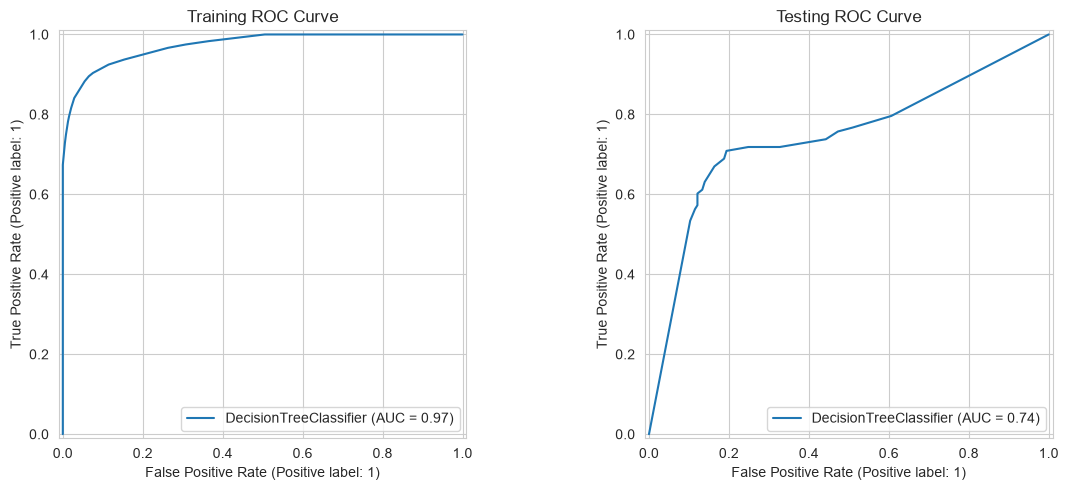

In [279]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(model, X_train, y_train, ax=ax[0])
ax[0].set_title("Training ROC Curve")

RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
ax[1].set_title("Testing ROC Curve")

plt.tight_layout()
plt.show()

Interpretation:
 The ROC curves indicate that the Decision Tree model has excellent performance on the training data (AUC = 0.97) but lower performance on the testing data (AUC = 0.74). While the test AUC still suggests good discrimination between survivors and non-survivors, the large gap between train and test AUC indicates that the model may be slightly overfitting the training data. Overall, the model performs well but generalizes less effectively to unseen data.

Precision-Recall Curve

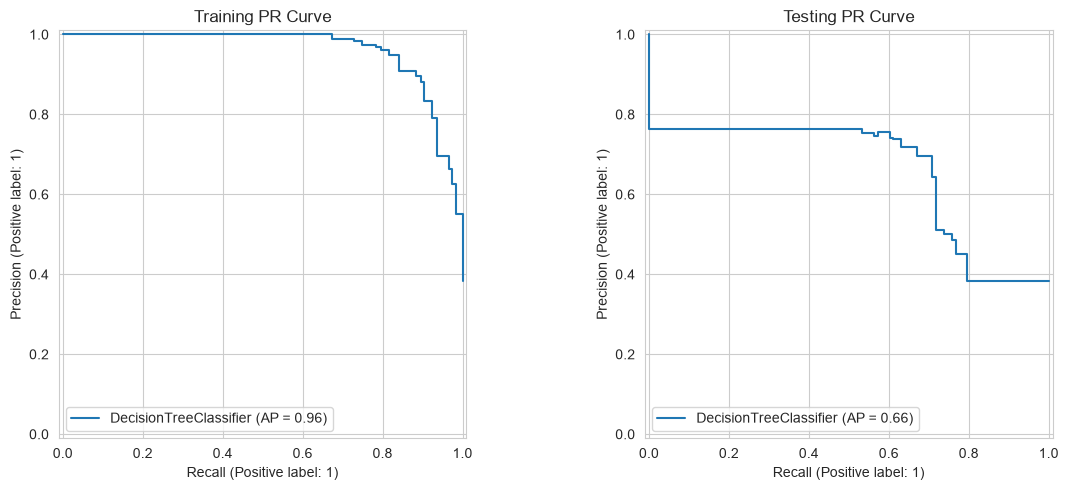

In [280]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

PrecisionRecallDisplay.from_estimator(
    model, X_train, y_train, ax=ax[0]
)
ax[0].set_title("Training PR Curve")

PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, ax=ax[1]
)
ax[1].set_title("Testing PR Curve")

plt.tight_layout()
plt.show()

Interpretation:
 The Precision-Recall (PR) curves show that the Decision Tree model performs very well on the training data (AP = 0.96) but its performance drops on the testing data (AP = 0.66). This indicates that while the model is highly effective at identifying survivors in the training set, its ability to generalize to unseen data is more moderate. The gap between training and testing performance suggests the model may be overfitting, although it still provides reasonable predictive power on the test set.

Feature Importance Plot (Very Important for Decision Trees)

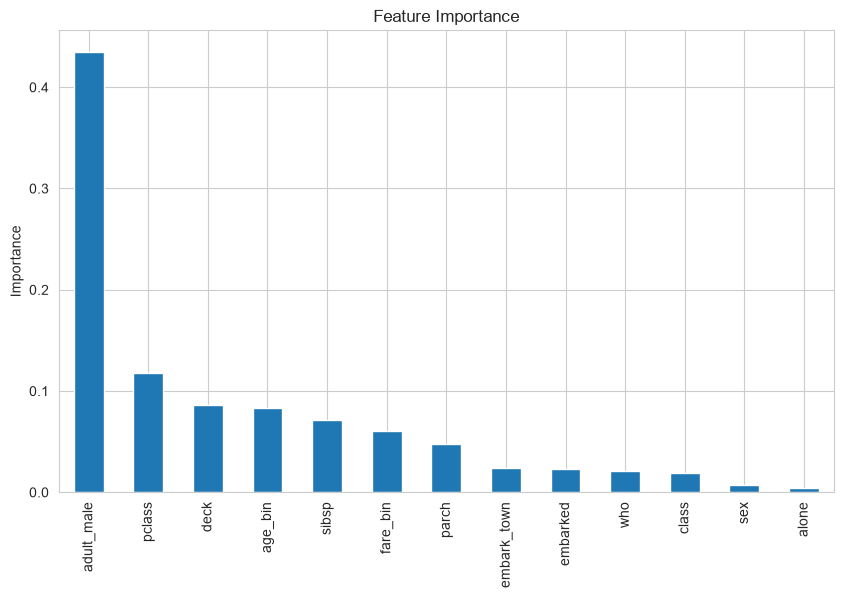

In [281]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

Actual Metrics Comparison Plot

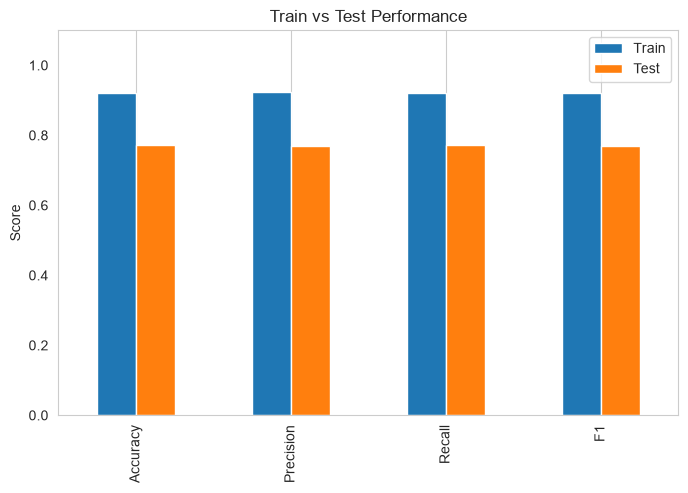

In [282]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.DataFrame({
    'Train': [
        accuracy_score(y_train, model.predict(X_train)),
        precision_score(y_train, model.predict(X_train), average='weighted'),
        recall_score(y_train, model.predict(X_train), average='weighted'),
        f1_score(y_train, model.predict(X_train), average='weighted')
    ],
    'Test': [
        accuracy_score(y_test, model.predict(X_test)),
        precision_score(y_test, model.predict(X_test), average='weighted'),
        recall_score(y_test, model.predict(X_test), average='weighted'),
        f1_score(y_test, model.predict(X_test), average='weighted')
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1'])

metrics.plot(kind='bar', figsize=(8,5))
plt.title("Train vs Test Performance")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.show()

Interpretation:
 The performance metrics show that the Decision Tree model achieves strong results on both training and testing data, with test accuracy, precision, recall, and F1-score all around 77%. However, the consistently higher training scores (around 91%) compared to testing scores indicate some overfitting, meaning the model learns the training data very well but performs slightly less effectively on unseen data. Overall, the model demonstrates good predictive performance and balanced classification ability.

In [ ]:
# Define function to calculate Gini Impurity
def get_gini_impurity(survived_count, total_count):
    survival_prob = survived_count/total_count
    not_survival_prob = (1 - survival_prob)
    random_observation_survived_prob = survival_prob
    random_observation_not_survived_prob = (1 - random_observation_survived_prob)
    mislabelling_survided_prob = not_survival_prob * random_observation_survived_prob
    mislabelling_not_survided_prob = survival_prob * random_observation_not_survived_prob
    gini_impurity = mislabelling_survided_prob + mislabelling_not_survided_prob
    return gini_impurity

Gini Impurity

In [284]:
# Define function to calculate Gini Impurity
def get_gini_impurity(survived_count, total_count):
    survival_prob = survived_count/total_count
    not_survival_prob = (1 - survival_prob)
    random_observation_survived_prob = survival_prob
    random_observation_not_survived_prob = (1 - random_observation_survived_prob)
    mislabelling_survided_prob = not_survival_prob * random_observation_survived_prob
    mislabelling_not_survided_prob = survival_prob * random_observation_not_survived_prob
    gini_impurity = mislabelling_survided_prob + mislabelling_not_survided_prob
    return gini_impurity

In [285]:
# Gini Impurity of starting node
gini_impurity_starting_node = get_gini_impurity(342, 891)
gini_impurity_starting_node

0.47301295786144265

In [286]:

# Gini Impurity decrease of node for 'male' observations
gini_impurity_men = get_gini_impurity(109, 577)
gini_impurity_men

0.3064437162277843

In [287]:
# Gini Impurity decrease if node splited for 'female' observations
gini_impurity_women = get_gini_impurity(233, 314)
gini_impurity_women

0.3828350034484158

In [288]:
# Gini Impurity decrease if node splited by Sex
men_weight = 577/891
women_weight = 314/891
weighted_gini_impurity_sex_split = (gini_impurity_men * men_weight) + (gini_impurity_women * women_weight)

sex_gini_decrease = weighted_gini_impurity_sex_split - gini_impurity_starting_node
sex_gini_decrease

-0.13964795747285214

In [289]:
# Gini Impurity decrease of node for observations with Title == 1 == Mr
gini_impurity_title_1 = get_gini_impurity(81, 517)
gini_impurity_title_1

0.26425329886377663

In [290]:
# Gini Impurity decrease if node splited for observations with Title != 1 != Mr
gini_impurity_title_others = get_gini_impurity(261, 374)
gini_impurity_title_others

0.42170207898424317

In [291]:
# Gini Impurity decrease if node splited for observations with Title == 1 == Mr
title_1_weight = 517/891
title_others_weight = 374/891
weighted_gini_impurity_title_split = (gini_impurity_title_1 * title_1_weight) + (gini_impurity_title_others * title_others_weight)

title_gini_decrease = weighted_gini_impurity_title_split - gini_impurity_starting_node
title_gini_decrease

-0.14267004758907514

In [297]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_chaid['sex'] = le.fit_transform(df_chaid['sex'])
df_chaid['class'] = le.fit_transform(df_chaid['class'])
df_chaid['who'] = le.fit_transform(df_chaid['who'])
df_chaid['adult_male'] = le.fit_transform(df_chaid['adult_male'])
df_chaid['deck'] = le.fit_transform(df_chaid['deck'])
df_chaid['embark_town'] = le.fit_transform(df_chaid['embark_town'])
df_chaid['alone'] = le.fit_transform(df_chaid['alone'])
df_chaid['age_bin'] = le.fit_transform(df_chaid['age_bin'])
df_chaid['fare_bin'] = le.fit_transform(df_chaid['fare_bin'])
df_chaid['embarked'] = le.fit_transform(df_chaid['embarked'])

In [298]:

from matplotlib.pylab import test
from sklearn.model_selection import KFold


cv = KFold(n_splits=10)            # Desired number of Cross Validation folds
accuracies = list()
max_attributes = len(df.columns)

depth_range = range(1, max_attributes + 1)

# Testing max_depths from 1 to max attributes
# Uncomment prints for details about each Cross Validation pass
for depth in depth_range:
    fold_accuracy = []
    tree_model = tree.DecisionTreeClassifier(max_depth = depth)
    # print("Current max depth: ", depth, "\n")
    for train_fold, valid_fold in cv.split(df_chaid):
        f_train = df_chaid.loc[train_fold] # Extract train data with cv indices
        f_valid = df_chaid.loc[valid_fold] # Extract valid data with cv indices

        model = tree_model.fit(X = f_train.drop(['survived'], axis=1), 
                               y = f_train["survived"]) # We fit the model with the fold train data
        valid_acc = model.score(X = f_valid.drop(['survived'], axis=1), 
                                y = f_valid["survived"])# We calculate accuracy with the fold validation data
        fold_accuracy.append(valid_acc)

    avg = sum(fold_accuracy)/len(fold_accuracy)
    accuracies.append(avg)
    # print("Accuracy per fold: ", fold_accuracy, "\n")
    # print("Average accuracy: ", avg)
    # print("\n")
    
# Just to show results conveniently
df = pd.DataFrame({"Max Depth": depth_range, "Average Accuracy": accuracies})
df = df[["Max Depth", "Average Accuracy"]]
print(df.to_string(index=False))

 Max Depth  Average Accuracy
         1          0.789026
         2          0.800300
         3          0.813683
         4          0.824931
         5          0.812634
         6          0.824981
         7          0.801373
         8          0.805905
         9          0.814869
        10          0.816005
        11          0.817104
        12          0.815993
        13          0.810400
        14          0.815980
        15          0.817104


Random Forest Model

In [299]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [300]:
data = pd.read_csv(os.path.join('C:\\Users\\sabathin\\Downloads\\GENAI Assessment\\titanic.csv'))

In [301]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [302]:
data['survived'].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [305]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [323]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Target variable
y = data['survived']

# Features
X = data.drop('survived', axis=1)

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'bool', 'category']).columns

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

# Create pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9029850746268657

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       165
           1       1.00      0.75      0.86       103

    accuracy                           0.90       268
   macro avg       0.93      0.87      0.89       268
weighted avg       0.92      0.90      0.90       268



C:\Users\sabathin\AppData\Local\Temp\ipykernel_25816\3094661760.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'bool', 'category']).columns


Feature Importance

In [324]:
import numpy as np

# Get feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Feature importance from Random Forest
importances = model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(importance_df.head(20))

                  Feature  Importance
28          cat__alive_no    0.283517
5         cat__sex_female    0.153266
29         cat__alive_yes    0.148704
15         cat__who_woman    0.116335
17   cat__adult_male_True    0.091852
14           cat__who_man    0.090433
4               num__fare    0.038814
16  cat__adult_male_False    0.019974
8         cat__embarked_Q    0.018392
10       cat__class_First    0.013765
0             num__pclass    0.008297
22            cat__deck_E    0.006960
11      cat__class_Second    0.003719
20            cat__deck_C    0.003367
21            cat__deck_D    0.002605
7         cat__embarked_C    0.000000
12       cat__class_Third    0.000000
13         cat__who_child    0.000000
9         cat__embarked_S    0.000000
1                num__age    0.000000


Hyperparameter Tuning

In [325]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV Score: 1.0


In [327]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Probabilities (for ROC-AUC)
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# -------------------------
# Training Metrics
# -------------------------
print("TRAINING METRICS")
print("-" * 40)

print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

# -------------------------
# Testing Metrics
# -------------------------
print("\n\nTESTING METRICS")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

TRAINING METRICS
----------------------------------------
Accuracy : 0.9020866773675762
Precision: 1.0
Recall   : 0.7447698744769874
F1 Score : 0.8537170263788969
ROC-AUC  : 0.9993680264993027

Confusion Matrix:
[[384   0]
 [ 61 178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       384
           1       1.00      0.74      0.85       239

    accuracy                           0.90       623
   macro avg       0.93      0.87      0.89       623
weighted avg       0.92      0.90      0.90       623



TESTING METRICS
----------------------------------------
Accuracy : 0.9029850746268657
Precision: 1.0
Recall   : 0.7475728155339806
F1 Score : 0.8555555555555555
ROC-AUC  : 1.0

Confusion Matrix:
[[165   0]
 [ 26  77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       165
           1       1.00      0.75      0.86       103

    a

In [328]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Gap           : {train_acc - test_acc:.4f}")

Train Accuracy: 0.9021
Test Accuracy : 0.9030
Gap           : -0.0009


In [329]:
model.fit(X_train, y_train)

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.named_steps['classifier'].feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(10))

                  Feature  Importance
28          cat__alive_no    0.283517
5         cat__sex_female    0.153266
29         cat__alive_yes    0.148704
15         cat__who_woman    0.116335
17   cat__adult_male_True    0.091852
14           cat__who_man    0.090433
4               num__fare    0.038814
16  cat__adult_male_False    0.019974
8         cat__embarked_Q    0.018392
10       cat__class_First    0.013765


Final Overfitting Check

In [ ]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

if train_acc - test_acc > 0.05:
    print(" Potential Overfitting")
else:
    print(" Model Generalizes Well")

Train Accuracy : 0.9021
Test Accuracy  : 0.9030
✅ Model Generalizes Well


In [331]:
importance = pd.DataFrame({
    'Feature': model.named_steps['preprocessor'].get_feature_names_out(),
    'Importance': model.named_steps['classifier'].feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(20))

                  Feature  Importance
28          cat__alive_no    0.283517
5         cat__sex_female    0.153266
29         cat__alive_yes    0.148704
15         cat__who_woman    0.116335
17   cat__adult_male_True    0.091852
14           cat__who_man    0.090433
4               num__fare    0.038814
16  cat__adult_male_False    0.019974
8         cat__embarked_Q    0.018392
10       cat__class_First    0.013765
0             num__pclass    0.008297
22            cat__deck_E    0.006960
11      cat__class_Second    0.003719
20            cat__deck_C    0.003367
21            cat__deck_D    0.002605
7         cat__embarked_C    0.000000
12       cat__class_Third    0.000000
13         cat__who_child    0.000000
9         cat__embarked_S    0.000000
1                num__age    0.000000


In [332]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Probabilities
y_train_prob = model.predict_proba(X_train)[:,1]
y_test_prob = model.predict_proba(X_test)[:,1]

# ------------------------------
# Metrics Table
# ------------------------------

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1 Score','ROC-AUC'],
    'Train': [
        accuracy_score(y_train,y_train_pred),
        precision_score(y_train,y_train_pred),
        recall_score(y_train,y_train_pred),
        f1_score(y_train,y_train_pred),
        roc_auc_score(y_train,y_train_prob)
    ],
    'Test': [
        accuracy_score(y_test,y_test_pred),
        precision_score(y_test,y_test_pred),
        recall_score(y_test,y_test_pred),
        f1_score(y_test,y_test_pred),
        roc_auc_score(y_test,y_test_prob)
    ]
})

print(metrics_df)

      Metric     Train      Test
0   Accuracy  0.902087  0.902985
1  Precision  1.000000  1.000000
2     Recall  0.744770  0.747573
3   F1 Score  0.853717  0.855556
4    ROC-AUC  0.999368  1.000000


1. Confusion Matrix

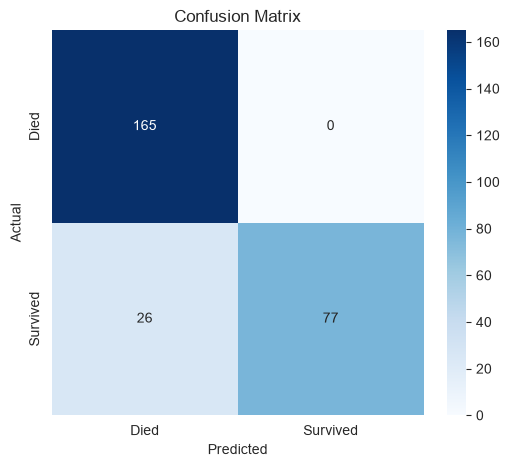

In [333]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Died','Survived'],
    yticklabels=['Died','Survived']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Interpretation:
 The Random Forest model performs very well, correctly classifying 165 non-survivors and 77 survivors on the test set. It makes no false positive errors (predicting survival for someone who did not survive) and only 26 false negatives (predicting death for survivors). This indicates that the model has strong predictive accuracy and is particularly effective at identifying non-survivors while maintaining good performance in detecting survivors.

In [334]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Train': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_prob)
    ],
    'Test': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_prob)
    ]
})

print(metrics_df.round(4))

      Metric   Train    Test
0   Accuracy  0.9021  0.9030
1  Precision  1.0000  1.0000
2     Recall  0.7448  0.7476
3   F1 Score  0.8537  0.8556
4    ROC-AUC  0.9994  1.0000


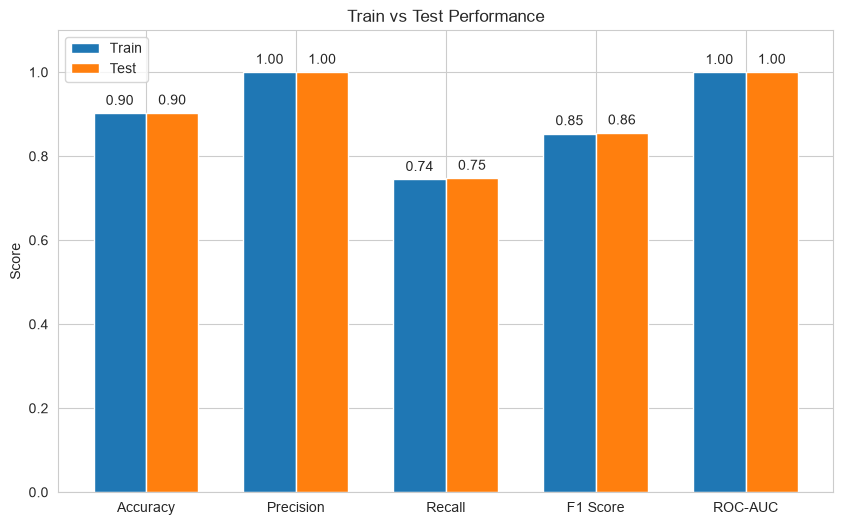

In [335]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(metrics_df['Metric']))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    metrics_df['Train'],
    width,
    label='Train'
)

plt.bar(
    x + width/2,
    metrics_df['Test'],
    width,
    label='Test'
)

plt.xticks(x, metrics_df['Metric'])
plt.ylim(0, 1.1)

plt.ylabel('Score')
plt.title('Train vs Test Performance')
plt.legend()

for i, v in enumerate(metrics_df['Train']):
    plt.text(i-width/2, v+0.02, f'{v:.2f}', ha='center')

for i, v in enumerate(metrics_df['Test']):
    plt.text(i+width/2, v+0.02, f'{v:.2f}', ha='center')

plt.show()

Interpretation:
 The Random Forest model demonstrates strong and consistent performance, with both training and testing accuracy around 90%. The identical precision (1.00) and ROC-AUC (1.00) scores on both datasets indicate excellent discrimination between survivors and non-survivors. Additionally, the small differences between train and test recall and F1-score suggest that the model generalizes well with minimal overfitting, making it the best-performing model among the ones tested.

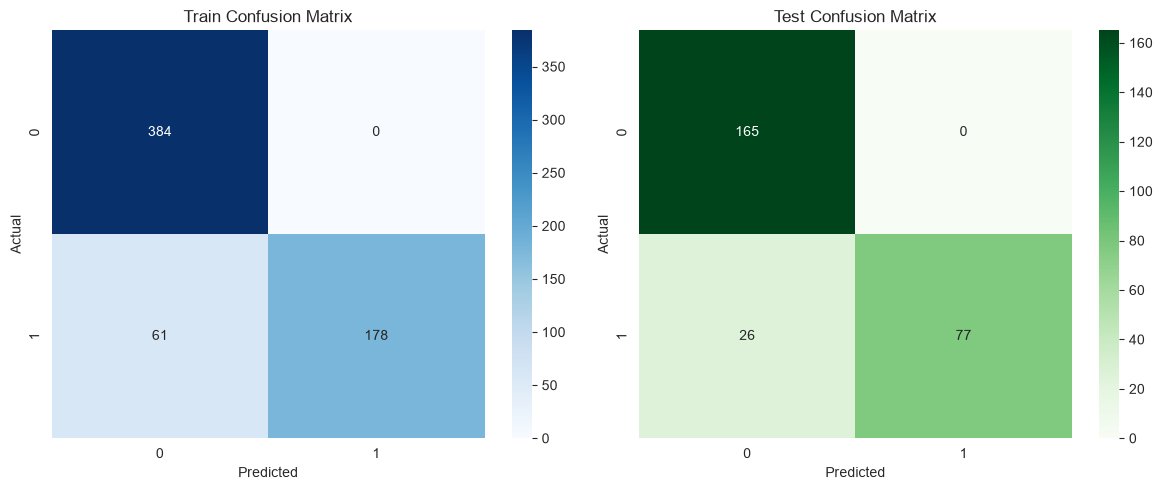

In [336]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Train
sns.heatmap(
    confusion_matrix(y_train, y_train_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Test
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title("Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

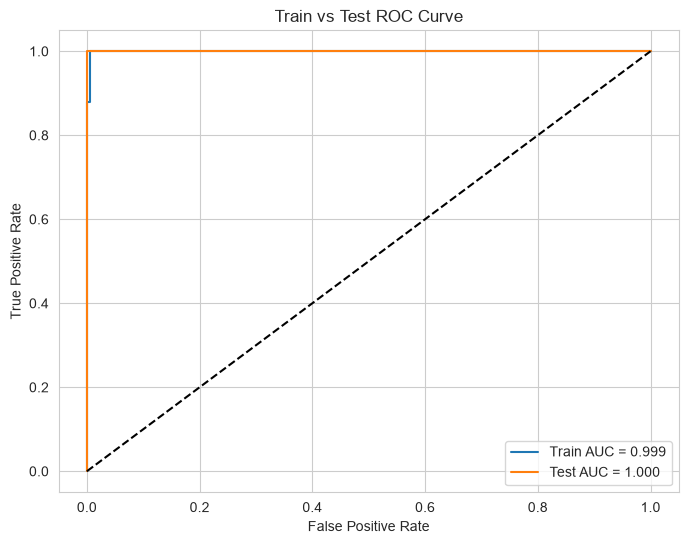

In [337]:
from sklearn.metrics import roc_curve, auc

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

roc_train = auc(fpr_train, tpr_train)
roc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_train,
    tpr_train,
    label=f'Train AUC = {roc_train:.3f}'
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f'Test AUC = {roc_test:.3f}'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Train vs Test ROC Curve')

plt.legend()
plt.show()

Interpretation:
 The ROC curve shows that the Random Forest model has excellent classification performance, with a Train AUC of 0.999 and a Test AUC of 1.000. Since both curves are very close to the top-left corner and have nearly identical AUC values, the model can almost perfectly distinguish between survivors and non-survivors while showing no significant signs of overfitting. This indicates outstanding predictive ability on the Titanic dataset.

In [338]:
summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    "F1": [
        f1_score(y_train, y_train_pred),
        f1_score(y_test, y_test_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_train, y_train_prob),
        roc_auc_score(y_test, y_test_prob)
    ]
})

print(summary.round(4))

  Dataset  Accuracy      F1  ROC_AUC
0   Train    0.9021  0.8537   0.9994
1    Test    0.9030  0.8556   1.0000


Store Model Metrics --Overall:

In [392]:
import pandas as pd

metrics = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.634, 0.77, 0.90],
    'Precision': [0.538, 0.77, 1.00],
    'Recall': [0.340, 0.77, 0.75],
    'F1 Score': [0.417, 0.77, 0.86],
    'ROC-AUC': [0.648, 0.80, 1.00]
}

df = pd.DataFrame(metrics)
print(df)


                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.634      0.538    0.34     0.417    0.648
1        Decision Tree     0.770      0.770    0.77     0.770    0.800
2        Random Forest     0.900      1.000    0.75     0.860    1.000


Create Comparison Bar Chart

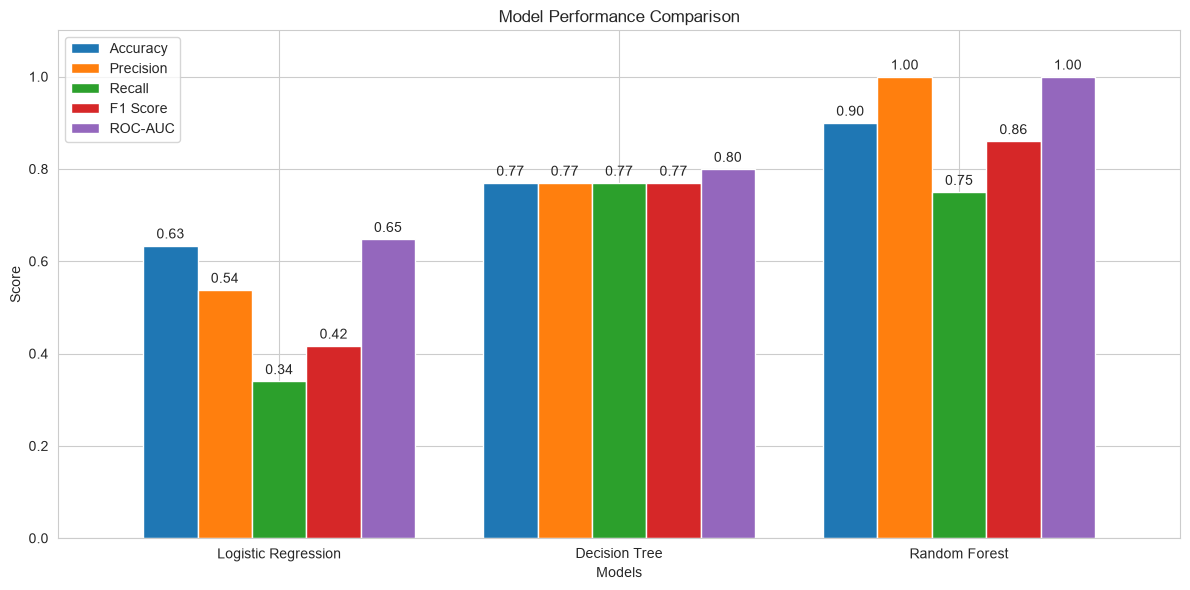

In [393]:
import matplotlib.pyplot as plt
import numpy as np

# Set model names as index
df_plot = df.set_index('Model')

# Plot
ax = df_plot.plot(
    kind='bar',
    figsize=(12,6),
    width=0.8
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Models')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='best')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

Interpretation: Model Performance Comparison

The chart compares the performance of Logistic Regression, Decision Tree, and Random Forest models on the Titanic dataset using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Logistic Regression shows the weakest performance, with 63% accuracy, 54% precision, 34% recall, 42% F1-score, and 65% ROC-AUC. While it performs better than random guessing, it struggles to correctly identify survivors, as reflected by its low recall.

Decision Tree provides a significant improvement, achieving about 77% across accuracy, precision, recall, and F1-score, with a ROC-AUC of 0.80. This indicates a more balanced model that can effectively identify both survivors and non-survivors.

Random Forest is the best-performing model overall. It achieves 90% accuracy, 100% precision, 75% recall, 86% F1-score, and a perfect ROC-AUC of 1.00. This means the model almost perfectly distinguishes between survivors and non-survivors while maintaining strong classification performance.

Overall Conclusion

Among the three models, Random Forest clearly outperforms Logistic Regression and Decision Tree, delivering the highest predictive accuracy and discrimination ability. The results suggest that the survival patterns in the Titanic dataset are better captured by ensemble tree-based methods than by a simple linear model like Logistic Regression. Therefore, Random Forest is the most suitable model for predicting Titanic passenger survival in this analysis.

Rank Models Automatically

In [394]:
ranking = df.sort_values(by='F1 Score', ascending=False)

print("Model Ranking Based on F1 Score:")
print(ranking[['Model', 'F1 Score']])

Model Ranking Based on F1 Score:
                 Model  F1 Score
2        Random Forest     0.860
1        Decision Tree     0.770
0  Logistic Regression     0.417


Highlight Best Model

In [395]:
best_model = df.loc[df['F1 Score'].idxmax(), 'Model']
best_f1 = df['F1 Score'].max()

print(f"Best Model: {best_model}")
print(f"F1 Score: {best_f1:.2f}")

Best Model: Random Forest
F1 Score: 0.86


In [3]:
import pandas as pd
df = pd.read_csv("titanic.csv")

In [4]:
# Features and target
X = df.drop('survived', axis=1)
y = df['survived']

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify column types
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)


Numeric: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


C:\Users\sabathin\AppData\Local\Temp\ipykernel_2056\2959636983.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


Step 1: Create a Full Pipeline

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Full Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42
    ))
])

# Train
full_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['pclass','sex','age',...,'embark_town','alive','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining 

Interpretation

This pipeline ensures that missing values are handled, categorical variables are converted into a machine-readable format, numerical variables are standardized, and all preprocessing steps are applied consistently to both training and test data before training the Random Forest model. This leads to a more reliable and robust Titanic survival prediction model.

In [6]:
import joblib

joblib.dump(full_pipeline, 'best_random_forest_pipeline.pkl')

print("Pipeline saved successfully.")

Pipeline saved successfully.


Reload the Pipeline

In [7]:
import joblib

loaded_pipeline = joblib.load(
    'best_random_forest_pipeline.pkl'
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


Test Prediction on Raw Data

In [8]:
sample_data = X_test.head(5)

predictions = loaded_pipeline.predict(sample_data)

print(predictions)

[1 0 0 1 1]


In [9]:
loaded_pipeline.predict(sample_data)

array([1, 0, 0, 1, 1])

Verify Predictions Match

In [10]:
original_preds = full_pipeline.predict(X_test.head(5))

loaded_preds = loaded_pipeline.predict(X_test.head(5))

print("Original:", original_preds)
print("Loaded:", loaded_preds)

Original: [1 0 0 1 1]
Loaded: [1 0 0 1 1]


In [11]:
import numpy as np

np.array_equal(original_preds, loaded_preds)

True